In [1]:
import sys
print(sys.executable)

c:\Users\HP\Downloads\solar\solar_env\Scripts\python.exe


In [2]:
import pandas as pd

# File path
file_path = r"C:\Users\HP\Downloads\solar\approah 1 fe datset.csv"

# Load dataset
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

# Optional: Check basic info
print(df.info())

          Datetime  Solar Radiation (All Sky)  Solar Radiation (Clear Sky)  \
0  10/5/2021 23:00                   0.473949                     0.473949   
1   10/6/2021 0:00                   0.473949                     0.473949   
2   10/6/2021 1:00                   0.473949                     0.473949   
3   10/6/2021 2:00                   0.473949                     0.473949   
4   10/6/2021 3:00                   0.473949                     0.473949   

   Air Temperature  Dew Point Temperature  Wet Bulb Temperature   Humidity  \
0         0.544041               0.568583               0.606423  0.290816   
1         0.524560               0.586989               0.603504  0.308390   
2         0.507772               0.603379               0.601168  0.324830   
3         0.494715               0.616742               0.599708  0.339569   
4         0.486218               0.628341               0.600292  0.352041   

   Precipitation  Wind Speed  Day of Week  ...  Wind Speed_Lag

In [3]:
# ==============================
# 🚀 FINAL MODEL TRAINING SCRIPT
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# ----------------------
# 📌 1. Load Data
# ----------------------
df = pd.read_csv("reduced_dataset.csv")

# Clean column names (fix LGBM warning)
df.columns = df.columns.str.replace(" ", "_")

target = "Solar_Radiation_(All_Sky)"

# ----------------------
# 📌 2. Features & Target
# ----------------------
X = df.drop(columns=[target])
y = df[target]

# ----------------------
# 📌 3. Train/Test Split
# ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------
# 📌 4. Define Models
# ----------------------
models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),

    "LGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    ),

    # 🌟 RandomForest + ExtraTrees Ensemble
    "RF+ExtraTrees": VotingRegressor([
        ("rf", RandomForestRegressor(n_estimators=200, random_state=42)),
        ("et", ExtraTreesRegressor(n_estimators=200, random_state=42))
    ])
}

# ----------------------
# 📌 5. Evaluation Function
# ----------------------
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    # Avoid division by zero in MAPE
    mask = y_test != 0
    mape = (np.abs((y_test[mask] - preds[mask]) / y_test[mask])).mean() * 100

    return r2, rmse, mae, mape

# ----------------------
# 📌 6. Train & Evaluate
# ----------------------
results = {}

for name, model in models.items():
    print(f"🚀 Training {name}...")
    r2, rmse, mae, mape = evaluate_model(model, X_train, X_test, y_train, y_test)

    results[name] = {
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_filtered": mape
    }

# ----------------------
# 📌 7. Results Table
# ----------------------
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="R2", ascending=False)

print("\n📊 Final Model Performance:\n")
print(results_df)

# ----------------------
# 📌 8. Save Results
# ----------------------
results_df.to_csv("model_results.csv")
print("\n✅ Results saved as 'model_results.csv'")

🚀 Training RandomForest...
🚀 Training XGBoost...
🚀 Training LGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000690 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5630
[LightGBM] [Info] Number of data points in the train set: 19930, number of used features: 24
[LightGBM] [Info] Start training from score 0.587303
🚀 Training CatBoost...
🚀 Training RF+ExtraTrees...

📊 Final Model Performance:

                     R2      RMSE       MAE  MAPE_filtered
LGBM           0.996714  0.009473  0.003667       0.533571
XGBoost        0.996445  0.009854  0.003787       0.549466
RF+ExtraTrees  0.996040  0.010399  0.003981       0.569848
CatBoost       0.995687  0.010854  0.004469       0.660035
RandomForest   0.994931  0.011766  0.004543       0.647655

✅ Results saved as 'model_results.csv'


In [4]:
import time
from tqdm import tqdm

print("📥 Loading libraries...")

import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional, Input
from scikeras.wrappers import KerasRegressor

print("✅ Libraries loaded")

# ----------------------
# TCN check
# ----------------------
try:
    from tcn import TCN
    TCN_AVAILABLE = True
    print("✅ TCN available")
except:
    TCN_AVAILABLE = False
    print("⚠️ TCN not available")

# ----------------------
# Load Data
# ----------------------
print("\n📂 Loading dataset...")
df = pd.read_csv("reduced_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")
print(f"✅ Dataset loaded: {df.shape}")

target = "Solar_Radiation_(All_Sky)"
X = df.drop(columns=[target])
y = df[target]

# ----------------------
# Split
# ----------------------
print("\n✂️ Splitting data...")
split = int(len(X) * 0.9)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ----------------------
# Scaling
# ----------------------
print("\n⚙️ Scaling data...")
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_seq = np.expand_dims(X_train_scaled, axis=1)
X_test_seq = np.expand_dims(X_test_scaled, axis=1)

print("✅ Scaling complete")

# ----------------------
# DL Models
# ----------------------
print("\n🧠 Building DL models...")

INPUT_SHAPE = (X_train_seq.shape[1], X_train_seq.shape[2])

def build_bilstm():
    model = Sequential([
        Input(shape=INPUT_SHAPE),  # 🔥 FIX
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bigru():
    model = Sequential([
        Input(shape=INPUT_SHAPE),  # 🔥 FIX
        Bidirectional(GRU(64, return_sequences=True)),
        Bidirectional(GRU(32)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_tcn():
    model = Sequential([
        Input(shape=INPUT_SHAPE),  # 🔥 FIX
        TCN(64),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# SciKeras models
bilstm = KerasRegressor(model=build_bilstm, epochs=10, batch_size=64, verbose=1)
bigru = KerasRegressor(model=build_bigru, epochs=10, batch_size=64, verbose=1)

if TCN_AVAILABLE:
    tcn_model = KerasRegressor(model=build_tcn, epochs=10, batch_size=64, verbose=1)

print("✅ DL models ready")

# ----------------------
# ML Models
# ----------------------
print("\n🌲 Initializing ML models...")

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, n_jobs=-1)
lgbm = LGBMRegressor(n_estimators=200, learning_rate=0.05)
cat = CatBoostRegressor(n_estimators=200, learning_rate=0.05, verbose=0)

print("✅ ML models ready")

# ----------------------
# Evaluation
# ----------------------
def safe_mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred):
    return [
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
        safe_mape(y_true, y_pred)
    ]

# =========================================================
# CASE 1: Hybrid DL + ML
# =========================================================
print("\n🚀 Case 1: DL → Boosting (Hybrid Mode)")

print("\n⏳ Training BiLSTM...")
bilstm.fit(X_train_seq, y_train)
bilstm_preds = bilstm.predict(X_test_seq)

print("\n⏳ Training BiGRU...")
bigru.fit(X_train_seq, y_train)
bigru_preds = bigru.predict(X_test_seq)

# Add DL predictions as features
X_train_hybrid = X_train.copy()
X_test_hybrid = X_test.copy()

X_train_hybrid["bilstm"] = bilstm.predict(X_train_seq)
X_train_hybrid["bigru"] = bigru.predict(X_train_seq)

X_test_hybrid["bilstm"] = bilstm_preds
X_test_hybrid["bigru"] = bigru_preds

meta_models_1 = {
    "DL_XGB": XGBRegressor(n_estimators=200),
    "DL_LGBM": LGBMRegressor(n_estimators=200),
    "DL_CatBoost": CatBoostRegressor(n_estimators=200, verbose=0)
}

results = {}

for name, meta in tqdm(meta_models_1.items(), desc="Case 1 Models"):
    start = time.time()

    meta.fit(X_train_hybrid, y_train)
    preds = meta.predict(X_test_hybrid)

    results[name] = evaluate(y_test, preds)

    print(f"✅ {name} done in {round(time.time() - start, 2)} sec")

# =========================================================
# CASE 2: ML Stacking
# =========================================================
print("\n🚀 Case 2: ML Stacking")

base_mix = [
    ("xgb", xgb),
    ("lgbm", lgbm),
    ("cat", cat)
]

meta_models_2 = {
    "Mix_RF": RandomForestRegressor(n_estimators=200),
    "Mix_ET": ExtraTreesRegressor(n_estimators=200)
}

for name, meta in tqdm(meta_models_2.items(), desc="Case 2 Models"):
    start = time.time()

    stack = StackingRegressor(
        estimators=base_mix,
        final_estimator=meta,
        n_jobs=-1
    )

    stack.fit(X_train, y_train)
    preds = stack.predict(X_test)

    results[name] = evaluate(y_test, preds)

    print(f"✅ {name} done in {round(time.time() - start, 2)} sec")

# ----------------------
# FINAL RESULTS
# ----------------------
print("\n📊 Compiling results...")

results_df = pd.DataFrame(
    results,
    index=["RMSE", "MAE", "R2", "MAPE"]
).T

print("\n🏆 FINAL RESULTS:\n")
print(results_df.sort_values(by="R2", ascending=False))

📥 Loading libraries...
✅ Libraries loaded
✅ TCN available

📂 Loading dataset...
✅ Dataset loaded: (24913, 25)

✂️ Splitting data...
Train: (22421, 24), Test: (2492, 24)

⚙️ Scaling data...
✅ Scaling complete

🧠 Building DL models...
✅ DL models ready

🌲 Initializing ML models...
✅ ML models ready

🚀 Case 1: DL → Boosting (Hybrid Mode)

⏳ Training BiLSTM...
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0128
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.9128e-04
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.4963e-04
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.1760e-04
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.0275e-04
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.0092e-04
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.8134e-04
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.8795e-04
Epoch 9/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6637e-04
Epoch 

Case 1 Models:  67%|██████▋   | 2/3 [00:00<00:00,  4.52it/s]

✅ DL_XGB done in 0.29 sec
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000788 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6140
[LightGBM] [Info] Number of data points in the train set: 22421, number of used features: 26
[LightGBM] [Info] Start training from score 0.588798
✅ DL_LGBM done in 0.17 sec


Case 1 Models: 100%|██████████| 3/3 [00:01<00:00,  2.72it/s]


✅ DL_CatBoost done in 0.64 sec

🚀 Case 2: ML Stacking


Case 2 Models:  50%|█████     | 1/2 [00:54<00:54, 54.08s/it]

✅ Mix_RF done in 54.08 sec


Case 2 Models: 100%|██████████| 2/2 [01:08<00:00, 34.16s/it]

✅ Mix_ET done in 14.23 sec

📊 Compiling results...

🏆 FINAL RESULTS:

                 RMSE       MAE        R2      MAPE
DL_XGB       0.009061  0.003958  0.998663  0.583241
DL_CatBoost  0.077149  0.025790  0.903083  0.562036
DL_LGBM      0.111707  0.035780  0.796811  0.472425
Mix_ET       0.139817  0.044777  0.681684  0.558705
Mix_RF       0.139823  0.044728  0.681654  0.547201


📂 Loading dataset...
✅ Dataset shape: (24913, 25)

🔍 Checking feature correlation with target...

🚨 TOP CORRELATED FEATURES:
Solar_Radiation_(Clear_Sky)        0.990047
Solar_Radiation_(All_Sky)_Lag_1    0.949953
Solar_Radiation_(All_Sky)_Lag_2    0.815067
Solar_Radiation_(All_Sky)_Lag_3    0.620982
Air_Temperature                    0.474718
Wet_Bulb_Temperature_              0.386085
Air_Temperature_Lag_1              0.383400
Air_Temperature_Lag_2              0.266136
Wind_Speed                         0.222342
Wind_Speed_Lag_1                   0.208571
dtype: float64

🚨 POSSIBLE LEAKAGE FEATURES (>0.95 correlation):
Solar_Radiation_(Clear_Sky)    0.990047
dtype: float64

🔍 Checking duplicates...
Duplicate rows: 0

🔍 Checking for target leakage columns...
🚨 Suspicious columns related to target:
['Solar_Radiation_(Clear_Sky)', 'Solar_Radiation_(All_Sky)_Lag_1', 'Solar_Radiation_(All_Sky)_Lag_2', 'Solar_Radiation_(All_Sky)_Lag_3', 'Fourier_Transform_Solar_Radiation']

🚀 Running RAND

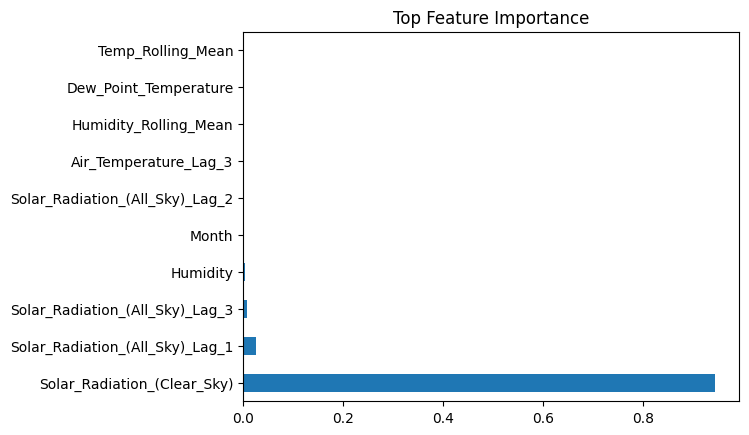


🧠 FINAL DIAGNOSIS:
🚨 VERY HIGH R² → Strong chance of leakage

✅ Leakage check complete


In [5]:
# ==============================
# 🔍 LEAKAGE + VALIDATION CHECK
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

print("📂 Loading dataset...")
df = pd.read_csv("reduced_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")

target = "Solar_Radiation_(All_Sky)"

X = df.drop(columns=[target])
y = df[target]

print(f"✅ Dataset shape: {df.shape}")

# =====================================================
# 🔥 1. CORRELATION CHECK (LEAKAGE DETECTION)
# =====================================================
print("\n🔍 Checking feature correlation with target...")

corr = X.corrwith(y).sort_values(ascending=False)

print("\n🚨 TOP CORRELATED FEATURES:")
print(corr.head(10))

# Flag suspicious features
high_corr = corr[abs(corr) > 0.95]

if len(high_corr) > 0:
    print("\n🚨 POSSIBLE LEAKAGE FEATURES (>0.95 correlation):")
    print(high_corr)
else:
    print("\n✅ No extreme correlation leakage detected")

# =====================================================
# 🔥 2. DUPLICATE ROW CHECK
# =====================================================
print("\n🔍 Checking duplicates...")

duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# =====================================================
# 🔥 3. TARGET LEAKAGE CHECK (COLUMN NAME BASED)
# =====================================================
print("\n🔍 Checking for target leakage columns...")

suspicious_cols = [col for col in X.columns if "solar" in col.lower()]

if suspicious_cols:
    print("🚨 Suspicious columns related to target:")
    print(suspicious_cols)
else:
    print("✅ No obvious target leakage columns")

# =====================================================
# 🔥 4. RANDOM SPLIT VALIDATION
# =====================================================
print("\n🚀 Running RANDOM SPLIT validation...")

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(n_estimators=200)
model.fit(X_train_r, y_train_r)

preds = model.predict(X_test_r)
r2_random = r2_score(y_test_r, preds)

print(f"📊 Random Split R²: {r2_random:.4f}")

# =====================================================
# 🔥 5. TIME-BASED SPLIT VALIDATION
# =====================================================
print("\n🚀 Running TIME SPLIT validation...")

split = int(len(X) * 0.9)

X_train_t, X_test_t = X.iloc[:split], X.iloc[split:]
y_train_t, y_test_t = y.iloc[:split], y.iloc[split:]

model = XGBRegressor(n_estimators=200)
model.fit(X_train_t, y_train_t)

preds = model.predict(X_test_t)
r2_time = r2_score(y_test_t, preds)

print(f"📊 Time Split R²: {r2_time:.4f}")

# =====================================================
# 🔥 6. BASELINE MODEL (SANITY CHECK)
# =====================================================
print("\n🔍 Running baseline model...")

y_mean = np.mean(y_train_r)
baseline_preds = np.full_like(y_test_r, y_mean)

baseline_r2 = r2_score(y_test_r, baseline_preds)

print(f"📊 Baseline R²: {baseline_r2:.4f}")

# =====================================================
# 🔥 7. FEATURE IMPORTANCE CHECK
# =====================================================
print("\n📊 Checking feature importance...")

model = XGBRegressor(n_estimators=200)
model.fit(X_train_r, y_train_r)

importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

print("\n🔥 TOP IMPORTANT FEATURES:")
print(top_features)

# Plot
top_features.plot(kind="barh")
plt.title("Top Feature Importance")
plt.show()

# =====================================================
# 🔥 FINAL DIAGNOSIS
# =====================================================
print("\n🧠 FINAL DIAGNOSIS:")

if r2_random > 0.98:
    print("🚨 VERY HIGH R² → Strong chance of leakage")

elif r2_random > 0.9:
    print("⚠️ High performance → Check carefully")

else:
    print("✅ Looks realistic")

if abs(r2_random - r2_time) > 0.1:
    print("🚨 Big gap between random & time split → temporal leakage")

print("\n✅ Leakage check complete")

In [6]:
import time
from tqdm import tqdm

print("📥 Loading libraries...")

import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional, Input
from scikeras.wrappers import KerasRegressor

print("✅ Libraries loaded")

# ----------------------
# Load Data
# ----------------------
print("\n📂 Loading dataset...")
df = pd.read_csv("reduced_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")

print(f"✅ Dataset loaded: {df.shape}")

target = "Solar_Radiation_(All_Sky)"

# 🚨 REMOVE LEAKAGE FEATURES
leakage_cols = [
    "Solar_Radiation_(Clear_Sky)",
    "Solar_Radiation_(All_Sky)_Lag_1",
    "Solar_Radiation_(All_Sky)_Lag_2",
    "Solar_Radiation_(All_Sky)_Lag_3",
    "Fourier_Transform_Solar_Radiation"
]

existing_cols = [col for col in leakage_cols if col in df.columns]

print(f"\n🚨 Removing leakage columns: {existing_cols}")
df = df.drop(columns=existing_cols)

# ----------------------
# Features
# ----------------------
X = df.drop(columns=[target])
y = df[target]

print(f"✅ Features after cleaning: {X.shape}")

# ----------------------
# RANDOM SPLIT (better validation)
# ----------------------
print("\n✂️ Splitting data (random)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ----------------------
# Scaling
# ----------------------
print("\n⚙️ Scaling data...")

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_seq = np.expand_dims(X_train_scaled, axis=1)
X_test_seq = np.expand_dims(X_test_scaled, axis=1)

print("✅ Scaling complete")

# ----------------------
# DL MODELS
# ----------------------
print("\n🧠 Building DL models...")

INPUT_SHAPE = (X_train_seq.shape[1], X_train_seq.shape[2])

def build_bilstm():
    model = Sequential([
        Input(shape=INPUT_SHAPE),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bigru():
    model = Sequential([
        Input(shape=INPUT_SHAPE),
        Bidirectional(GRU(64, return_sequences=True)),
        Bidirectional(GRU(32)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

bilstm = KerasRegressor(model=build_bilstm, epochs=5, batch_size=64, verbose=1)
bigru = KerasRegressor(model=build_bigru, epochs=5, batch_size=64, verbose=1)

print("✅ DL models ready")

# ----------------------
# ML MODELS
# ----------------------
print("\n🌲 Initializing ML models...")

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, n_jobs=-1)
lgbm = LGBMRegressor(n_estimators=200, learning_rate=0.05)
cat = CatBoostRegressor(n_estimators=200, learning_rate=0.05, verbose=0)

print("✅ ML models ready")

# ----------------------
# Evaluation
# ----------------------
def safe_mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred):
    return [
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
        safe_mape(y_true, y_pred)
    ]

# =========================================================
# CASE 1: DL + ML Hybrid
# =========================================================
print("\n🚀 Case 1: DL → Boosting (Clean)")

print("\n⏳ Training BiLSTM...")
bilstm.fit(X_train_seq, y_train)
bilstm_preds = bilstm.predict(X_test_seq)

print("\n⏳ Training BiGRU...")
bigru.fit(X_train_seq, y_train)
bigru_preds = bigru.predict(X_test_seq)

# Add DL predictions as features
X_train_hybrid = X_train.copy()
X_test_hybrid = X_test.copy()

X_train_hybrid["bilstm"] = bilstm.predict(X_train_seq)
X_train_hybrid["bigru"] = bigru.predict(X_train_seq)

X_test_hybrid["bilstm"] = bilstm_preds
X_test_hybrid["bigru"] = bigru_preds

meta_models = {
    "DL_XGB": XGBRegressor(n_estimators=200),
    "DL_LGBM": LGBMRegressor(n_estimators=200),
    "DL_CatBoost": CatBoostRegressor(n_estimators=200, verbose=0)
}

results = {}

for name, model in tqdm(meta_models.items(), desc="Hybrid Models"):
    start = time.time()

    model.fit(X_train_hybrid, y_train)
    preds = model.predict(X_test_hybrid)

    results[name] = evaluate(y_test, preds)

    print(f"✅ {name} done in {round(time.time() - start, 2)} sec")

# =========================================================
# CASE 2: ML STACKING
# =========================================================
print("\n🚀 Case 2: ML Stacking")

base_models = [
    ("xgb", xgb),
    ("lgbm", lgbm),
    ("cat", cat)
]

meta_models_2 = {
    "Mix_RF": RandomForestRegressor(n_estimators=200),
    "Mix_ET": ExtraTreesRegressor(n_estimators=200)
}

for name, meta in tqdm(meta_models_2.items(), desc="Stacking Models"):
    start = time.time()

    stack = StackingRegressor(
        estimators=base_models,
        final_estimator=meta,
        n_jobs=-1
    )

    stack.fit(X_train, y_train)
    preds = stack.predict(X_test)

    results[name] = evaluate(y_test, preds)

    print(f"✅ {name} done in {round(time.time() - start, 2)} sec")

# ----------------------
# FINAL RESULTS
# ----------------------
print("\n📊 Compiling results...")

results_df = pd.DataFrame(
    results,
    index=["RMSE", "MAE", "R2", "MAPE"]
).T

print("\n🏆 FINAL CLEAN RESULTS:\n")
print(results_df.sort_values(by="R2", ascending=False))

📥 Loading libraries...
✅ Libraries loaded

📂 Loading dataset...
✅ Dataset loaded: (24913, 25)

🚨 Removing leakage columns: ['Solar_Radiation_(Clear_Sky)', 'Solar_Radiation_(All_Sky)_Lag_1', 'Solar_Radiation_(All_Sky)_Lag_2', 'Solar_Radiation_(All_Sky)_Lag_3', 'Fourier_Transform_Solar_Radiation']
✅ Features after cleaning: (24913, 19)

✂️ Splitting data (random)...
Train: (19930, 19), Test: (4983, 19)

⚙️ Scaling data...
✅ Scaling complete

🧠 Building DL models...
✅ DL models ready

🌲 Initializing ML models...
✅ ML models ready

🚀 Case 1: DL → Boosting (Clean)

⏳ Training BiLSTM...
Epoch 1/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0339
Epoch 2/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0078
Epoch 3/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0066
Epoch 4/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0065
Epoch 5/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0064
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

⏳ Training BiGRU...
Epoch 1/5
312/312 ━━━━

Hybrid Models:  33%|███▎      | 1/3 [00:00<00:00,  2.32it/s]

✅ DL_XGB done in 0.43 sec
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001731 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4865
[LightGBM] [Info] Number of data points in the train set: 19930, number of used features: 21
[LightGBM] [Info] Start training from score 0.587303


Hybrid Models:  67%|██████▋   | 2/3 [00:00<00:00,  2.86it/s]

✅ DL_LGBM done in 0.29 sec


...

✅ DL_CatBoost done in 0.98 sec

🚀 Case 2: ML Stacking


Stacking Models:  50%|█████     | 1/2 [00:21<00:21, 21.42s/it]

✅ Mix_RF done in 21.42 sec


Stacking Models: 100%|██████████| 2/2 [00:32<00:00, 16.49s/it]

✅ Mix_ET done in 11.56 sec

📊 Compiling results...

🏆 FINAL CLEAN RESULTS:

                 RMSE       MAE        R2      MAPE
DL_CatBoost  0.041159  0.021897  0.937975  3.183567
Mix_RF       0.042024  0.019560  0.935343  2.764194
DL_LGBM      0.043001  0.020699  0.932300  2.837784
DL_XGB       0.043879  0.021069  0.929508  2.963831
Mix_ET       0.044816  0.020466  0.926465  2.852360


✅ All libraries loaded
✅ Data ready: (24913, 19)

🚀 RUN 1/3
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001525 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4865
[LightGBM] [Info] Number of data points in the train set: 19930, number of used features: 21
[LightGBM] [Info] Start training from score 0.586568

🚀 RUN 2/3
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4865
[LightGBM] [Info] Number of data points in the train set: 19930, number of used features: 21
[LightGBM] [Info] Start training from score 0.587232

🚀 RUN 3/3
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4865
[LightGBM] [Info] Number of data point

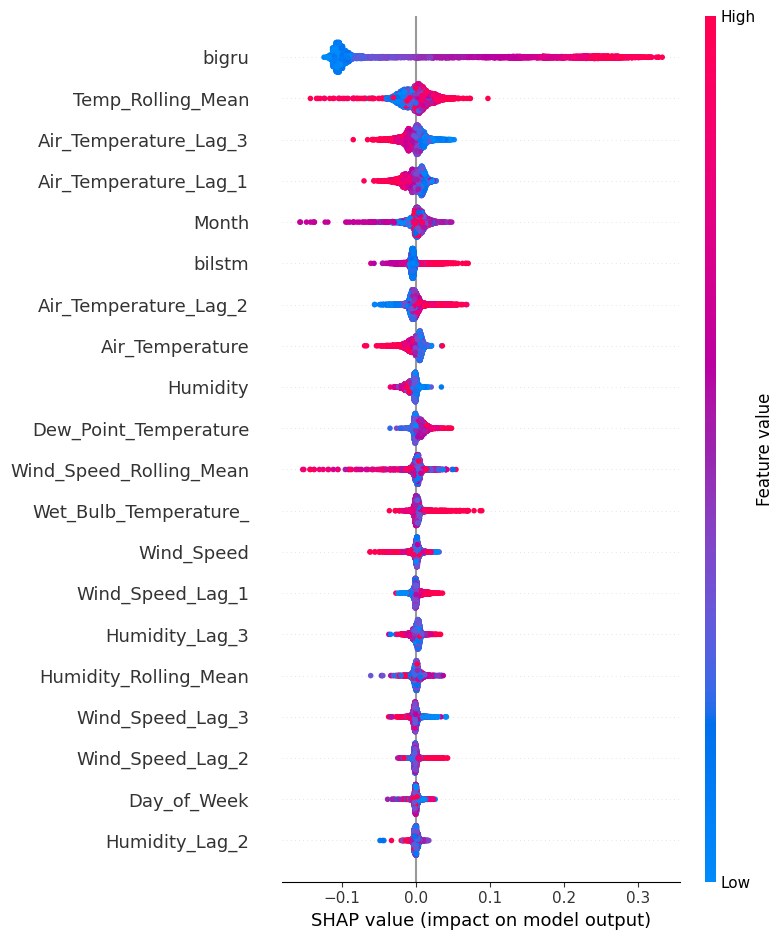


📊 Statistical Test (DL_XGB vs Mix_RF)
T-statistic: 29.9894
P-value: 0.001110
✅ Statistically significant improvement


In [7]:
# =========================================
# 🚀 FINAL RESEARCH PIPELINE (FULL)
# =========================================

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import MinMaxScaler

from scipy.stats import ttest_rel

import shap
import matplotlib.pyplot as plt

# DL
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional, Input
from scikeras.wrappers import KerasRegressor

print("✅ All libraries loaded")

# =========================================
# 📂 LOAD DATA
# =========================================
df = pd.read_csv("reduced_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")

target = "Solar_Radiation_(All_Sky)"

# 🚨 REMOVE LEAKAGE
leakage_cols = [
    "Solar_Radiation_(Clear_Sky)",
    "Solar_Radiation_(All_Sky)_Lag_1",
    "Solar_Radiation_(All_Sky)_Lag_2",
    "Solar_Radiation_(All_Sky)_Lag_3",
    "Fourier_Transform_Solar_Radiation"
]

df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

X = df.drop(columns=[target])
y = df[target]

print(f"✅ Data ready: {X.shape}")

# =========================================
# 🧠 DL MODELS
# =========================================
def build_bilstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bigru(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(GRU(64, return_sequences=True)),
        Bidirectional(GRU(32)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# =========================================
# 📊 METRICS
# =========================================
def evaluate(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# =========================================
# 🔁 REPEATED RUNS
# =========================================
N_RUNS = 3

all_results = []

for run in range(N_RUNS):
    print(f"\n🚀 RUN {run+1}/{N_RUNS}")

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=run
    )

    # Scale
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_seq = np.expand_dims(X_train_scaled, axis=1)
    X_test_seq = np.expand_dims(X_test_scaled, axis=1)

    INPUT_SHAPE = (X_train_seq.shape[1], X_train_seq.shape[2])

    # DL models
    bilstm = KerasRegressor(
        model=lambda: build_bilstm(INPUT_SHAPE),
        epochs=3, batch_size=64, verbose=0
    )

    bigru = KerasRegressor(
        model=lambda: build_bigru(INPUT_SHAPE),
        epochs=3, batch_size=64, verbose=0
    )

    # Train DL
    bilstm.fit(X_train_seq, y_train)
    bigru.fit(X_train_seq, y_train)

    # Predictions
    bilstm_train = bilstm.predict(X_train_seq)
    bilstm_test = bilstm.predict(X_test_seq)

    bigru_train = bigru.predict(X_train_seq)
    bigru_test = bigru.predict(X_test_seq)

    # =====================================
    # CASE 1: DL → Boosting
    # =====================================
    X_train_h = X_train.copy()
    X_test_h = X_test.copy()

    X_train_h["bilstm"] = bilstm_train
    X_train_h["bigru"] = bigru_train

    X_test_h["bilstm"] = bilstm_test
    X_test_h["bigru"] = bigru_test

    models_case1 = {
        "DL_XGB": XGBRegressor(n_estimators=200),
        "DL_LGBM": LGBMRegressor(n_estimators=200),
        "DL_CatBoost": CatBoostRegressor(verbose=0, n_estimators=200)
    }

    for name, model in models_case1.items():
        model.fit(X_train_h, y_train)
        preds = model.predict(X_test_h)

        metrics = evaluate(y_test, preds)
        metrics["Model"] = name
        all_results.append(metrics)

    # =====================================
    # CASE 2: ML + DL → RF/ET
    # =====================================
    X_train_mix = X_train_h
    X_test_mix = X_test_h

    models_case2 = {
        "Mix_RF": RandomForestRegressor(n_estimators=200),
        "Mix_ET": ExtraTreesRegressor(n_estimators=200)
    }

    for name, model in models_case2.items():
        model.fit(X_train_mix, y_train)
        preds = model.predict(X_test_mix)

        metrics = evaluate(y_test, preds)
        metrics["Model"] = name
        all_results.append(metrics)

# =========================================
# 📊 MEAN ± STD
# =========================================
results_df = pd.DataFrame(all_results)

summary = results_df.groupby("Model").agg(["mean", "std"])

print("\n🏆 FINAL RESULTS (Mean ± Std):\n")
print(summary)

# =========================================
# 📈 SHAP ANALYSIS (on best model)
# =========================================
print("\n🔍 Running SHAP analysis...")

best_model = XGBRegressor(n_estimators=200)
best_model.fit(X_train_h, y_train)

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test_h)

shap.summary_plot(shap_values, X_test_h)

# =========================================
# 📊 STATISTICAL TEST (paired t-test)
# =========================================
print("\n📊 Statistical Test (DL_XGB vs Mix_RF)")

model1 = results_df[results_df["Model"] == "DL_XGB"]["R2"]
model2 = results_df[results_df["Model"] == "Mix_RF"]["R2"]

t_stat, p_val = ttest_rel(model1, model2)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.6f}")

if p_val < 0.05:
    print("✅ Statistically significant improvement")
else:
    print("⚠️ Not statistically significant")

In [8]:
# =========================================
# 🔧 BLOCK 1: OPTUNA OPTIMIZATION FOR BASE MODELS
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Load data
df = pd.read_csv("reduced_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")

target = "Solar_Radiation_(All_Sky)"
leakage_cols = [
    "Solar_Radiation_(Clear_Sky)",
    "Solar_Radiation_(All_Sky)_Lag_1",
    "Solar_Radiation_(All_Sky)_Lag_2",
    "Solar_Radiation_(All_Sky)_Lag_3",
    "Fourier_Transform_Solar_Radiation"
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

X = df.drop(columns=[target])
y = df[target]

# Fixed split for optimization
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Data ready: X_train={X_train.shape}, X_test={X_test.shape}")

# ---- XGBoost ----
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "n_jobs": -1
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
    return scores.mean()

print("\n🔧 Optimizing XGBoost...")
study_xgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)
best_xgb_params = study_xgb.best_params
print(f"✅ Best XGB R2 (CV): {study_xgb.best_value:.4f}")
print(f"   Params: {best_xgb_params}")

# ---- LightGBM ----
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }
    model = LGBMRegressor(**params, verbose=-1)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
    return scores.mean()

print("\n🔧 Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=30, show_progress_bar=True)
best_lgbm_params = study_lgbm.best_params
print(f"✅ Best LGBM R2 (CV): {study_lgbm.best_value:.4f}")
print(f"   Params: {best_lgbm_params}")

# ---- CatBoost ----
def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-4, 10.0, log=True),
        "verbose": 0,
        "random_state": 42
    }
    model = CatBoostRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
    return scores.mean()

print("\n🔧 Optimizing CatBoost...")
study_cat = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True)
best_cat_params = study_cat.best_params
print(f"✅ Best CatBoost R2 (CV): {study_cat.best_value:.4f}")
print(f"   Params: {best_cat_params}")

# ---- Meta-learners (RF & ET) ----
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
    return scores.mean()

print("\n🔧 Optimizing RandomForest meta-learner...")
study_rf = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)
best_rf_params = study_rf.best_params
print(f"✅ Best RF R2 (CV): {study_rf.best_value:.4f}")

def objective_et(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
    }
    model = ExtraTreesRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
    return scores.mean()

print("\n🔧 Optimizing ExtraTrees meta-learner...")
study_et = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_et.optimize(objective_et, n_trials=20, show_progress_bar=True)
best_et_params = study_et.best_params
print(f"✅ Best ET R2 (CV): {study_et.best_value:.4f}")

print("\n✅ BLOCK 1 COMPLETE - All hyperparameters tuned")
print("\n📋 SUMMARY OF BEST PARAMS:")
print(f"XGB:      {best_xgb_params}")
print(f"LGBM:     {best_lgbm_params}")
print(f"CatBoost: {best_cat_params}")
print(f"RF:       {best_rf_params}")
print(f"ET:       {best_et_params}")

✅ Data ready: X_train=(19930, 19), X_test=(4983, 19)

🔧 Optimizing XGBoost...


Best trial: 21. Best value: 0.923404: 100%|██████████| 30/30 [01:30<00:00,  3.01s/it]


✅ Best XGB R2 (CV): 0.9234
   Params: {'n_estimators': 457, 'learning_rate': 0.07016151467062384, 'max_depth': 8, 'subsample': 0.658694617558437, 'colsample_bytree': 0.9357120255732487, 'reg_alpha': 1.0221065240233134, 'reg_lambda': 0.00013246539576788124}

🔧 Optimizing LightGBM...


Best trial: 27. Best value: 0.92078: 100%|██████████| 30/30 [01:11<00:00,  2.40s/it] 


✅ Best LGBM R2 (CV): 0.9208
   Params: {'n_estimators': 482, 'learning_rate': 0.08092895312499687, 'max_depth': 6, 'num_leaves': 108, 'subsample': 0.5460101277993696, 'colsample_bytree': 0.9835027623102178, 'reg_alpha': 0.007317081857637643, 'reg_lambda': 0.02622569833903139}

🔧 Optimizing CatBoost...


...

✅ Best CatBoost R2 (CV): 0.9386
   Params: {'iterations': 493, 'learning_rate': 0.10435882230584723, 'depth': 10, 'l2_leaf_reg': 0.8859012849344982}

🔧 Optimizing RandomForest meta-learner...


Best trial: 17. Best value: 0.883655: 100%|██████████| 20/20 [02:07<00:00,  6.38s/it]


✅ Best RF R2 (CV): 0.8837

🔧 Optimizing ExtraTrees meta-learner...


Best trial: 17. Best value: 0.87522: 100%|██████████| 20/20 [00:27<00:00,  1.35s/it]

✅ Best ET R2 (CV): 0.8752

✅ BLOCK 1 COMPLETE - All hyperparameters tuned

📋 SUMMARY OF BEST PARAMS:
XGB:      {'n_estimators': 457, 'learning_rate': 0.07016151467062384, 'max_depth': 8, 'subsample': 0.658694617558437, 'colsample_bytree': 0.9357120255732487, 'reg_alpha': 1.0221065240233134, 'reg_lambda': 0.00013246539576788124}
LGBM:     {'n_estimators': 482, 'learning_rate': 0.08092895312499687, 'max_depth': 6, 'num_leaves': 108, 'subsample': 0.5460101277993696, 'colsample_bytree': 0.9835027623102178, 'reg_alpha': 0.007317081857637643, 'reg_lambda': 0.02622569833903139}
CatBoost: {'iterations': 493, 'learning_rate': 0.10435882230584723, 'depth': 10, 'l2_leaf_reg': 0.8859012849344982}
RF:       {'n_estimators': 400, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None}
ET:       {'n_estimators': 400, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None}


In [9]:
# =========================================
# 🔧 BLOCK 2: 3-RUN FULL RESULTS TABLE
# Unoptimised vs Optimised | Base + Meta
# Config 1: DL + Boosting | Config 2: ML Stacking
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional, Input
from scikeras.wrappers import KerasRegressor

# ---- Data ----
df = pd.read_csv("reduced_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")
target = "Solar_Radiation_(All_Sky)"
leakage_cols = [
    "Solar_Radiation_(Clear_Sky)",
    "Solar_Radiation_(All_Sky)_Lag_1",
    "Solar_Radiation_(All_Sky)_Lag_2",
    "Solar_Radiation_(All_Sky)_Lag_3",
    "Fourier_Transform_Solar_Radiation"
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
X = df.drop(columns=[target])
y = df[target]

# ---- Metrics ----
def evaluate(y_true, y_pred):
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mape
    }

# ---- DL builders ----
def build_bilstm(input_shape):
    m = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def build_bigru(input_shape):
    m = Sequential([
        Input(shape=input_shape),
        Bidirectional(GRU(64, return_sequences=True)),
        Bidirectional(GRU(32)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

# ---- Param sets ----
UNOPT = {
    "XGB":  dict(n_estimators=200, learning_rate=0.05, max_depth=5, n_jobs=-1),
    "LGBM": dict(n_estimators=200, learning_rate=0.05, verbose=-1),
    "CAT":  dict(iterations=200, learning_rate=0.05, verbose=0, random_state=42),
    "RF":   dict(n_estimators=200, random_state=42, n_jobs=-1),
    "ET":   dict(n_estimators=200, random_state=42, n_jobs=-1),
}

OPT = {
    "XGB":  {**best_xgb_params, "n_jobs": -1},
    "LGBM": {**best_lgbm_params, "verbose": -1},
    "CAT":  {**best_cat_params, "verbose": 0, "random_state": 42},
    "RF":   {**best_rf_params, "random_state": 42, "n_jobs": -1},
    "ET":   {**best_et_params, "random_state": 42, "n_jobs": -1},
}
# Rename CatBoost key from iterations→iterations (already fine), just handle n_estimators vs iterations
if "n_estimators" in OPT["CAT"]:
    OPT["CAT"]["iterations"] = OPT["CAT"].pop("n_estimators")
if "n_estimators" in UNOPT["CAT"]:
    UNOPT["CAT"]["iterations"] = UNOPT["CAT"].pop("n_estimators")

N_RUNS = 3

all_records = []  # store every row

for version, params in [("Unoptimised", UNOPT), ("Optimised", OPT)]:
    print(f"\n{'='*50}")
    print(f"🚀 VERSION: {version}")
    print(f"{'='*50}")

    for run in range(N_RUNS):
        print(f"\n  ▶ Run {run+1}/{N_RUNS}")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=run
        )

        scaler = MinMaxScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)
        X_train_seq = np.expand_dims(X_train_s, axis=1)
        X_test_seq  = np.expand_dims(X_test_s, axis=1)
        INPUT_SHAPE = (X_train_seq.shape[1], X_train_seq.shape[2])

        # ---- Train DL ----
        bilstm = KerasRegressor(model=lambda: build_bilstm(INPUT_SHAPE),
                                epochs=5, batch_size=64, verbose=0)
        bigru  = KerasRegressor(model=lambda: build_bigru(INPUT_SHAPE),
                                epochs=5, batch_size=64, verbose=0)
        bilstm.fit(X_train_seq, y_train)
        bigru.fit(X_train_seq,  y_train)

        # ---- Base model results (standalone) ----
        for name, cls, p in [
            ("BiLSTM",   None,              None),
            ("BiGRU",    None,              None),
            ("XGBoost",  XGBRegressor,      params["XGB"]),
            ("LGBM",     LGBMRegressor,     params["LGBM"]),
            ("CatBoost", CatBoostRegressor, params["CAT"]),
            ("RF",       RandomForestRegressor, params["RF"]),
            ("ET",       ExtraTreesRegressor,   params["ET"]),
        ]:
            if cls is None:
                preds = bilstm.predict(X_test_seq) if name == "BiLSTM" else bigru.predict(X_test_seq)
            else:
                m = cls(**p)
                m.fit(X_train, y_train)
                preds = m.predict(X_test)

            metrics = evaluate(y_test, preds)
            metrics.update({"Version": version, "Run": run+1,
                            "Type": "Base", "Model": name,
                            "Config": "Both"})
            all_records.append(metrics)

        # ---- Hybrid features ----
        X_train_h = X_train.copy()
        X_test_h  = X_test.copy()
        X_train_h["bilstm"] = bilstm.predict(X_train_seq)
        X_train_h["bigru"]  = bigru.predict(X_train_seq)
        X_test_h["bilstm"]  = bilstm.predict(X_test_seq)
        X_test_h["bigru"]   = bigru.predict(X_test_seq)

        # ---- CONFIG 1: DL + Boosting (meta-learner on hybrid) ----
        for name, cls, p in [
            ("DL_XGB",     XGBRegressor,      params["XGB"]),
            ("DL_LGBM",    LGBMRegressor,     params["LGBM"]),
            ("DL_CatBoost",CatBoostRegressor, params["CAT"]),
        ]:
            m = cls(**p)
            m.fit(X_train_h, y_train)
            preds = m.predict(X_test_h)
            metrics = evaluate(y_test, preds)
            metrics.update({"Version": version, "Run": run+1,
                            "Type": "MetaLearner", "Model": name,
                            "Config": "Config1_DL_Boosting"})
            all_records.append(metrics)

        # ---- CONFIG 2: ML Stacking (XGB+LGBM+CAT → RF/ET) ----
        base_stack = [
            ("xgb",  XGBRegressor(**params["XGB"])),
            ("lgbm", LGBMRegressor(**params["LGBM"])),
            ("cat",  CatBoostRegressor(**params["CAT"])),
        ]
        for name, meta_cls, p in [
            ("Mix_RF", RandomForestRegressor, params["RF"]),
            ("Mix_ET", ExtraTreesRegressor,   params["ET"]),
        ]:
            stack = StackingRegressor(
                estimators=base_stack,
                final_estimator=meta_cls(**p),
                n_jobs=-1
            )
            stack.fit(X_train, y_train)
            preds = stack.predict(X_test)
            metrics = evaluate(y_test, preds)
            metrics.update({"Version": version, "Run": run+1,
                            "Type": "MetaLearner", "Model": name,
                            "Config": "Config2_ML_Stacking"})
            all_records.append(metrics)

        print(f"  ✅ Run {run+1} complete")

# =========================================
# 📊 COMPILE RESULTS TABLES
# =========================================
full_df = pd.DataFrame(all_records)
full_df.to_csv("full_results_all_runs.csv", index=False)
print("\n✅ All results saved to full_results_all_runs.csv")

# ---- Summary: Mean ± SD ----
def fmt(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

summary = full_df.groupby(["Version","Config","Type","Model"]).agg(
    RMSE_mean=("RMSE","mean"), RMSE_std=("RMSE","std"),
    MAE_mean=("MAE","mean"),  MAE_std=("MAE","std"),
    R2_mean=("R2","mean"),    R2_std=("R2","std"),
    MAPE_mean=("MAPE","mean"),MAPE_std=("MAPE","std"),
).reset_index()

summary["RMSE"] = summary.apply(lambda r: fmt(r.RMSE_mean, r.RMSE_std), axis=1)
summary["MAE"]  = summary.apply(lambda r: fmt(r.MAE_mean,  r.MAE_std),  axis=1)
summary["R²"]   = summary.apply(lambda r: fmt(r.R2_mean,   r.R2_std),   axis=1)
summary["MAPE"] = summary.apply(lambda r: fmt(r.MAPE_mean, r.MAPE_std), axis=1)

display_cols = ["Version","Config","Type","Model","R²","RMSE","MAE","MAPE"]
print("\n\n📊 TABLE 1 — BASE MODELS (Mean ± SD, 3 Runs)")
print("="*80)
base_tbl = summary[summary["Type"]=="Base"][display_cols]
print(base_tbl.to_string(index=False))

print("\n\n📊 TABLE 2 — META-LEARNERS Config 1: DL + Boosting (Mean ± SD, 3 Runs)")
print("="*80)
meta1_tbl = summary[(summary["Type"]=="MetaLearner") &
                    (summary["Config"]=="Config1_DL_Boosting")][display_cols]
print(meta1_tbl.to_string(index=False))

print("\n\n📊 TABLE 3 — META-LEARNERS Config 2: ML Stacking (Mean ± SD, 3 Runs)")
print("="*80)
meta2_tbl = summary[(summary["Type"]=="MetaLearner") &
                    (summary["Config"]=="Config2_ML_Stacking")][display_cols]
print(meta2_tbl.to_string(index=False))

print("\n✅ BLOCK 2 COMPLETE")


🚀 VERSION: Unoptimised

  ▶ Run 1/3
  ✅ Run 1 complete

  ▶ Run 2/3
  ✅ Run 2 complete

  ▶ Run 3/3
  ✅ Run 3 complete

🚀 VERSION: Optimised

  ▶ Run 1/3
  ✅ Run 1 complete

  ▶ Run 2/3
  ✅ Run 2 complete

  ▶ Run 3/3
  ✅ Run 3 complete

✅ All results saved to full_results_all_runs.csv


📊 TABLE 1 — BASE MODELS (Mean ± SD, 3 Runs)
    Version Config Type    Model              R²            RMSE             MAE            MAPE
  Optimised   Both Base    BiGRU 0.7765 ± 0.0182 0.0785 ± 0.0039 0.0460 ± 0.0019 6.8649 ± 0.2707
  Optimised   Both Base   BiLSTM 0.7748 ± 0.0161 0.0788 ± 0.0036 0.0470 ± 0.0039 6.9318 ± 0.6015
  Optimised   Both Base CatBoost 0.9548 ± 0.0038 0.0353 ± 0.0015 0.0192 ± 0.0001 2.8461 ± 0.0580
  Optimised   Both Base       ET 0.8855 ± 0.0063 0.0562 ± 0.0021 0.0243 ± 0.0003 3.1471 ± 0.0557
  Optimised   Both Base     LGBM 0.9368 ± 0.0047 0.0418 ± 0.0017 0.0214 ± 0.0001 3.0813 ± 0.0641
  Optimised   Both Base       RF 0.8996 ± 0.0085 0.0526 ± 0.0027 0.0202 ± 0.0005 2.5

🔍 Computing SHAP values...


100%|===================| 4968/4983 [02:55<00:00]        


📊 Mean |SHAP| per feature:
bigru                      0.085780
bilstm                     0.024969
Air_Temperature_Lag_3      0.012434
Temp_Rolling_Mean          0.008683
Month                      0.008617
Wind_Speed_Rolling_Mean    0.005187
Air_Temperature_Lag_2      0.004840
Air_Temperature            0.004560
Wind_Speed                 0.003430
Humidity_Rolling_Mean      0.003418
Air_Temperature_Lag_1      0.003386
Wind_Speed_Lag_1           0.002735
Wind_Speed_Lag_3           0.002641
Humidity_Lag_3             0.002578
Wet_Bulb_Temperature_      0.002340
Wind_Speed_Lag_2           0.002050
Dew_Point_Temperature      0.001704
Day_of_Week                0.001456
Humidity                   0.001155
Humidity_Lag_2             0.000991
Humidity_Lag_1             0.000662
dtype: float64


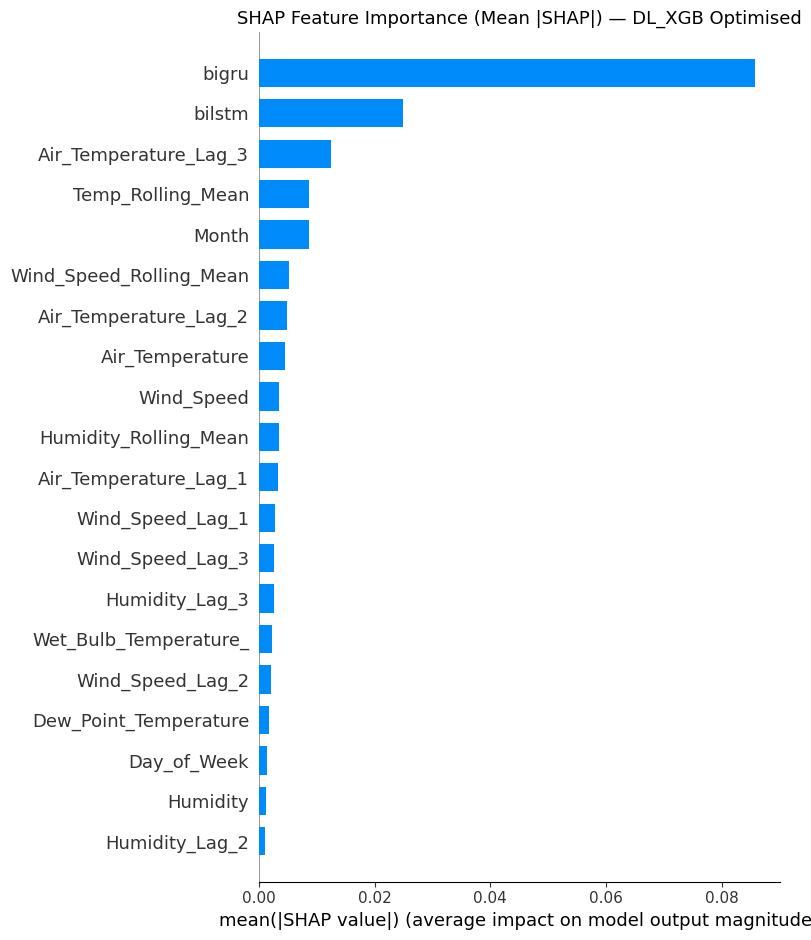

✅ Saved: shap_bar_dl_xgb_opt.png


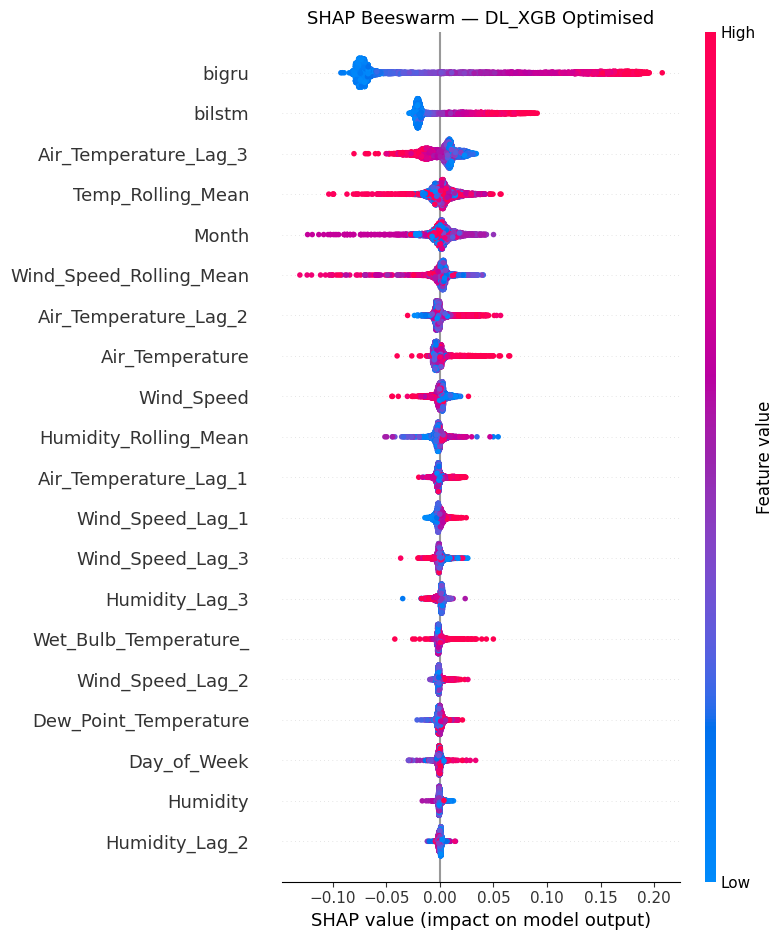

✅ Saved: shap_beeswarm_dl_xgb_opt.png

🔥 Generating SHAP Heatmap...


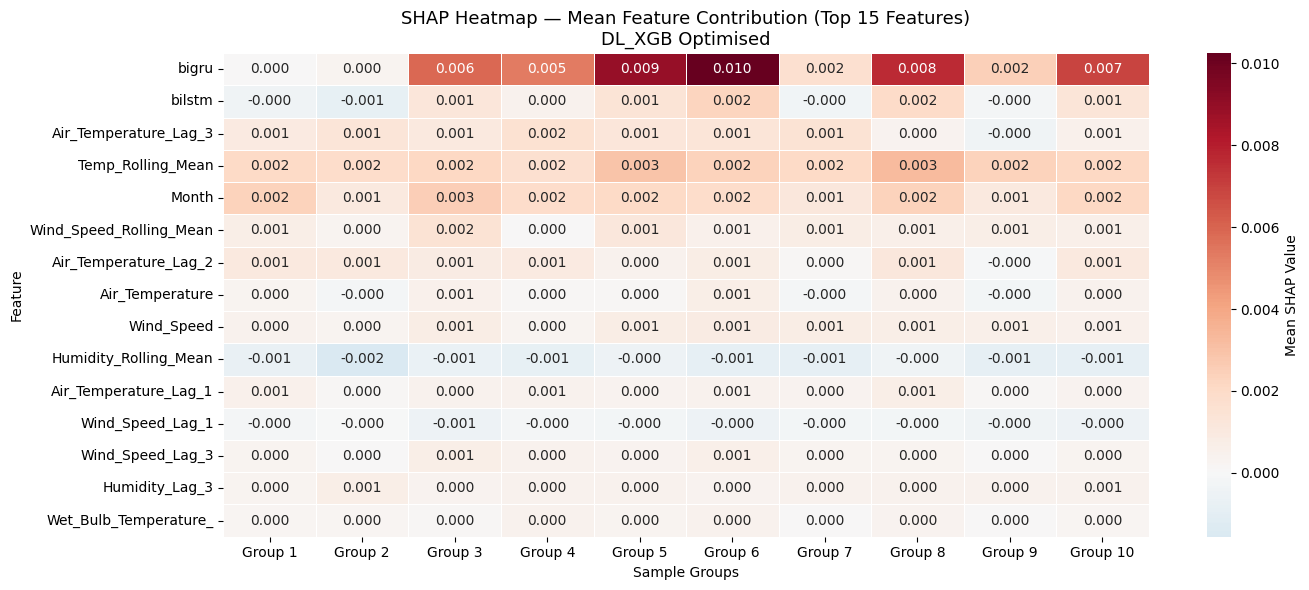

✅ Saved: shap_heatmap_dl_xgb_opt.png

📋 Mean Absolute SHAP Table:
 Rank                 Feature  Mean |SHAP|
    1                   bigru     0.085780
    2                  bilstm     0.024969
    3   Air_Temperature_Lag_3     0.012434
    4       Temp_Rolling_Mean     0.008683
    5                   Month     0.008617
    6 Wind_Speed_Rolling_Mean     0.005187
    7   Air_Temperature_Lag_2     0.004840
    8         Air_Temperature     0.004560
    9              Wind_Speed     0.003430
   10   Humidity_Rolling_Mean     0.003418
   11   Air_Temperature_Lag_1     0.003386
   12        Wind_Speed_Lag_1     0.002735
   13        Wind_Speed_Lag_3     0.002641
   14          Humidity_Lag_3     0.002578
   15   Wet_Bulb_Temperature_     0.002340
   16        Wind_Speed_Lag_2     0.002050
   17   Dew_Point_Temperature     0.001704
   18             Day_of_Week     0.001456
   19                Humidity     0.001155
   20          Humidity_Lag_2     0.000991
   21          Humidity_Lag_1  

In [10]:
# =========================================
# 🔧 BLOCK 3: SHAP MEAN ABSOLUTE HEATMAP
# Best model = DL_XGB (Config 1, Optimised)
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional, Input
from scikeras.wrappers import KerasRegressor

# ---- Data ----
df = pd.read_csv("reduced_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")
target = "Solar_Radiation_(All_Sky)"
leakage_cols = [
    "Solar_Radiation_(Clear_Sky)",
    "Solar_Radiation_(All_Sky)_Lag_1",
    "Solar_Radiation_(All_Sky)_Lag_2",
    "Solar_Radiation_(All_Sky)_Lag_3",
    "Fourier_Transform_Solar_Radiation"
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_train_seq = np.expand_dims(X_train_s, axis=1)
X_test_seq  = np.expand_dims(X_test_s, axis=1)
INPUT_SHAPE = (X_train_seq.shape[1], X_train_seq.shape[2])

# ---- Rebuild DL ----
def build_bilstm():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def build_bigru():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Bidirectional(GRU(64, return_sequences=True)),
        Bidirectional(GRU(32)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

bilstm = KerasRegressor(model=build_bilstm, epochs=5, batch_size=64, verbose=0)
bigru  = KerasRegressor(model=build_bigru,  epochs=5, batch_size=64, verbose=0)
bilstm.fit(X_train_seq, y_train)
bigru.fit(X_train_seq,  y_train)

X_train_h = X_train.copy()
X_test_h  = X_test.copy()
X_train_h["bilstm"] = bilstm.predict(X_train_seq)
X_train_h["bigru"]  = bigru.predict(X_train_seq)
X_test_h["bilstm"]  = bilstm.predict(X_test_seq)
X_test_h["bigru"]   = bigru.predict(X_test_seq)

# ---- Train best model with optimised params ----
best_model = XGBRegressor(**OPT["XGB"])   # uses OPT from Block 1
best_model.fit(X_train_h, y_train)

# ---- SHAP ----
print("🔍 Computing SHAP values...")
explainer = shap.Explainer(best_model, X_train_h)
shap_values = explainer(X_test_h)

shap_df = pd.DataFrame(shap_values.values, columns=X_test_h.columns)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print("\n📊 Mean |SHAP| per feature:")
print(mean_abs_shap)

# ---- SHAP Bar Summary Plot ----
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_h, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — DL_XGB Optimised", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar_dl_xgb_opt.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_bar_dl_xgb_opt.png")

# ---- SHAP Beeswarm ----
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_h, show=False)
plt.title("SHAP Beeswarm — DL_XGB Optimised", fontsize=13)
plt.tight_layout()
plt.savefig("shap_beeswarm_dl_xgb_opt.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_beeswarm_dl_xgb_opt.png")

# ---- SHAP HEATMAP (Mean |SHAP| across top features, per sample group) ----
print("\n🔥 Generating SHAP Heatmap...")

TOP_N = 15
top_features = mean_abs_shap.head(TOP_N).index.tolist()

shap_top = shap_df[top_features]

# Bin samples into 10 groups for heatmap rows
n_bins = 10
bin_labels = [f"Group {i+1}" for i in range(n_bins)]
shap_top = shap_top.copy()
shap_top["bin"] = pd.cut(range(len(shap_top)), bins=n_bins, labels=bin_labels)
heatmap_data = shap_top.groupby("bin")[top_features].mean()

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data.T,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Mean SHAP Value"}
)
plt.title("SHAP Heatmap — Mean Feature Contribution (Top 15 Features)\nDL_XGB Optimised", fontsize=13)
plt.xlabel("Sample Groups")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("shap_heatmap_dl_xgb_opt.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_heatmap_dl_xgb_opt.png")

# ---- Mean Absolute SHAP Table ----
shap_table = mean_abs_shap.reset_index()
shap_table.columns = ["Feature", "Mean |SHAP|"]
shap_table["Rank"] = range(1, len(shap_table)+1)
print("\n📋 Mean Absolute SHAP Table:")
print(shap_table[["Rank","Feature","Mean |SHAP|"]].to_string(index=False))
shap_table.to_csv("shap_mean_abs_table.csv", index=False)
print("✅ Saved: shap_mean_abs_table.csv")

print("\n✅ BLOCK 3 COMPLETE")

In [11]:
# =========================================
# 🔧 BLOCK 4: STATISTICAL SIGNIFICANCE TESTS
# Paired t-test:
#   (a) Config1 Optimised vs Config1 Unoptimised
#   (b) Config2 Optimised vs Config2 Unoptimised
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon

# Load from saved CSV (produced in Block 2)
full_df = pd.read_csv("full_results_all_runs.csv")

print("="*60)
print("📊 STATISTICAL SIGNIFICANCE TESTS")
print("Metric used: R²  |  Runs: 3  |  Test: Paired t-test")
print("="*60)

def run_tests(label_a, label_b, data_a, data_b):
    """Run paired t-test and Wilcoxon between two model sets across runs."""
    r2_a = data_a["R2"].values
    r2_b = data_b["R2"].values

    print(f"\n🔬 {label_a}  vs  {label_b}")
    print(f"   {label_a} R² (per run): {np.round(r2_a, 4)}")
    print(f"   {label_b} R² (per run): {np.round(r2_b, 4)}")

    if len(r2_a) < 2 or len(r2_b) < 2 or len(r2_a) != len(r2_b):
        print("   ⚠️ Insufficient paired data")
        return

    t_stat, p_val = ttest_rel(r2_a, r2_b)
    print(f"\n   Paired t-test:")
    print(f"   T-statistic : {t_stat:.4f}")
    print(f"   P-value     : {p_val:.6f}")
    print(f"   Significant : {'✅ YES (p < 0.05)' if p_val < 0.05 else '❌ NO (p ≥ 0.05)'}")

    try:
        w_stat, w_p = wilcoxon(r2_a, r2_b)
        print(f"\n   Wilcoxon signed-rank test:")
        print(f"   W-statistic : {w_stat:.4f}")
        print(f"   P-value     : {w_p:.6f}")
        print(f"   Significant : {'✅ YES (p < 0.05)' if w_p < 0.05 else '❌ NO (p ≥ 0.05)'}")
    except Exception as e:
        print(f"   ⚠️ Wilcoxon not possible: {e}")

    delta = r2_a.mean() - r2_b.mean()
    print(f"\n   Mean R² difference ({label_a} − {label_b}): {delta:+.4f}")

# ---- Get per-run R2 for each model & version ----
def get_runs(version, config, model):
    return full_df[
        (full_df["Version"] == version) &
        (full_df["Config"].str.contains(config)) &
        (full_df["Model"] == model)
    ].sort_values("Run")

# =============================================
# TEST 1: Config 1 — DL_XGB Opt vs Unopt
# =============================================
print("\n" + "="*60)
print("TEST GROUP 1: CONFIG 1 (DL + Boosting)")
print("="*60)

for model in ["DL_XGB", "DL_LGBM", "DL_CatBoost"]:
    opt   = get_runs("Optimised",   "Config1", model)
    unopt = get_runs("Unoptimised", "Config1", model)
    run_tests(f"{model} Optimised", f"{model} Unoptimised", opt, unopt)

# =============================================
# TEST 2: Config 2 — Stacking Opt vs Unopt
# =============================================
print("\n" + "="*60)
print("TEST GROUP 2: CONFIG 2 (ML Stacking)")
print("="*60)

for model in ["Mix_RF", "Mix_ET"]:
    opt   = get_runs("Optimised",   "Config2", model)
    unopt = get_runs("Unoptimised", "Config2", model)
    run_tests(f"{model} Optimised", f"{model} Unoptimised", opt, unopt)

# =============================================
# TEST 3: Best Config1 vs Best Config2 (Optimised)
# =============================================
print("\n" + "="*60)
print("TEST GROUP 3: BEST Config1 vs BEST Config2 (Optimised)")
print("="*60)

opt_c1 = get_runs("Optimised", "Config1", "DL_XGB")
opt_c2 = get_runs("Optimised", "Config2", "Mix_RF")
run_tests("DL_XGB Optimised (C1)", "Mix_RF Optimised (C2)", opt_c1, opt_c2)

# =============================================
# SUMMARY TABLE
# =============================================
print("\n\n📋 SUMMARY TABLE — Mean R² per Model (Unopt vs Opt)")
print("="*60)

rows = []
for version in ["Unoptimised", "Optimised"]:
    for config, models in [
        ("Config1_DL_Boosting",  ["DL_XGB","DL_LGBM","DL_CatBoost"]),
        ("Config2_ML_Stacking",  ["Mix_RF","Mix_ET"]),
    ]:
        for model in models:
            sub = full_df[
                (full_df["Version"]==version) &
                (full_df["Config"]==config) &
                (full_df["Model"]==model)
            ]
            if len(sub):
                rows.append({
                    "Version": version,
                    "Config": config,
                    "Model": model,
                    "Mean R²": f"{sub['R2'].mean():.4f}",
                    "Std R²":  f"{sub['R2'].std():.4f}",
                    "Mean RMSE": f"{sub['RMSE'].mean():.4f}",
                    "Mean MAE":  f"{sub['MAE'].mean():.4f}",
                })

stat_summary = pd.DataFrame(rows)
print(stat_summary.to_string(index=False))
stat_summary.to_csv("statistical_summary.csv", index=False)
print("\n✅ Saved: statistical_summary.csv")
print("\n✅ BLOCK 4 COMPLETE")

📊 STATISTICAL SIGNIFICANCE TESTS
Metric used: R²  |  Runs: 3  |  Test: Paired t-test

TEST GROUP 1: CONFIG 1 (DL + Boosting)

🔬 DL_XGB Optimised  vs  DL_XGB Unoptimised
   DL_XGB Optimised R² (per run): [0.943  0.9388 0.9391]
   DL_XGB Unoptimised R² (per run): [0.9001 0.8964 0.9052]

   Paired t-test:
   T-statistic : 13.6500
   P-value     : 0.005324
   Significant : ✅ YES (p < 0.05)

   Wilcoxon signed-rank test:
   W-statistic : 0.0000
   P-value     : 0.250000
   Significant : ❌ NO (p ≥ 0.05)

   Mean R² difference (DL_XGB Optimised − DL_XGB Unoptimised): +0.0397

🔬 DL_LGBM Optimised  vs  DL_LGBM Unoptimised
   DL_LGBM Optimised R² (per run): [0.9347 0.9382 0.9372]
   DL_LGBM Unoptimised R² (per run): [0.9207 0.923  0.9292]

   Paired t-test:
   T-statistic : 5.6350
   P-value     : 0.030079
   Significant : ✅ YES (p < 0.05)

   Wilcoxon signed-rank test:
   W-statistic : 0.0000
   P-value     : 0.250000
   Significant : ❌ NO (p ≥ 0.05)

   Mean R² difference (DL_LGBM Optimised − 

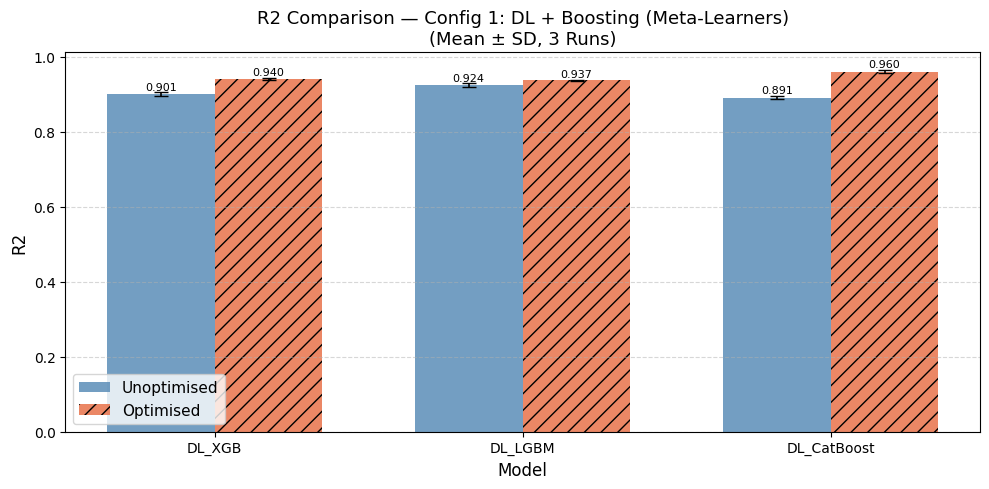

✅ Saved: plot_config1_meta_R2.png


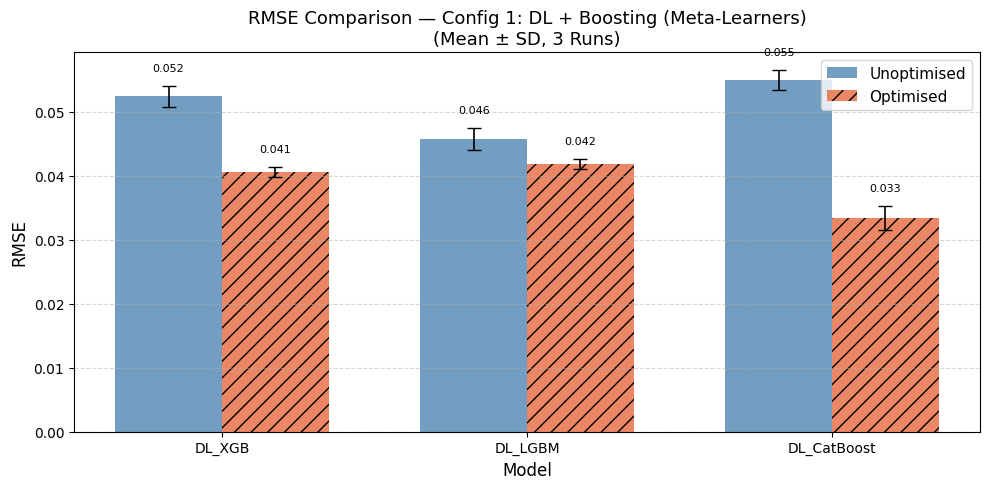

✅ Saved: plot_config1_meta_RMSE.png


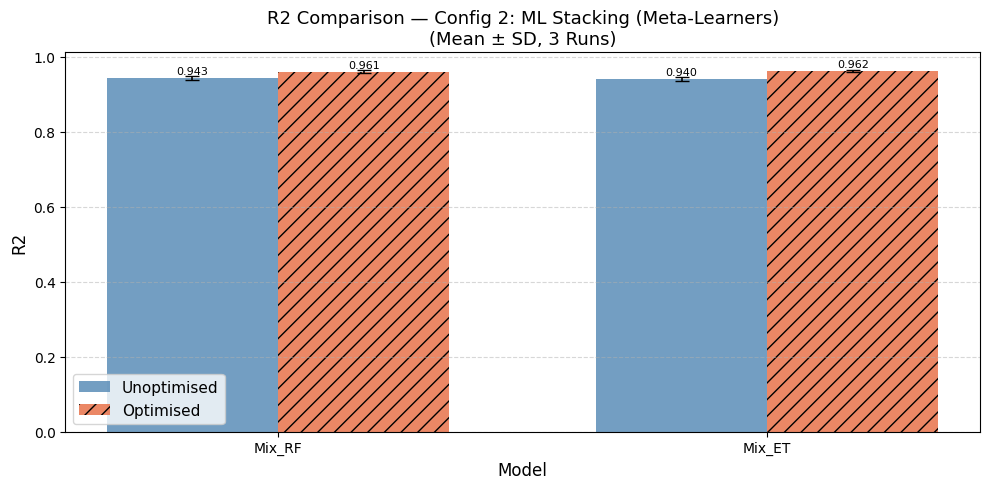

✅ Saved: plot_config2_meta_R2.png


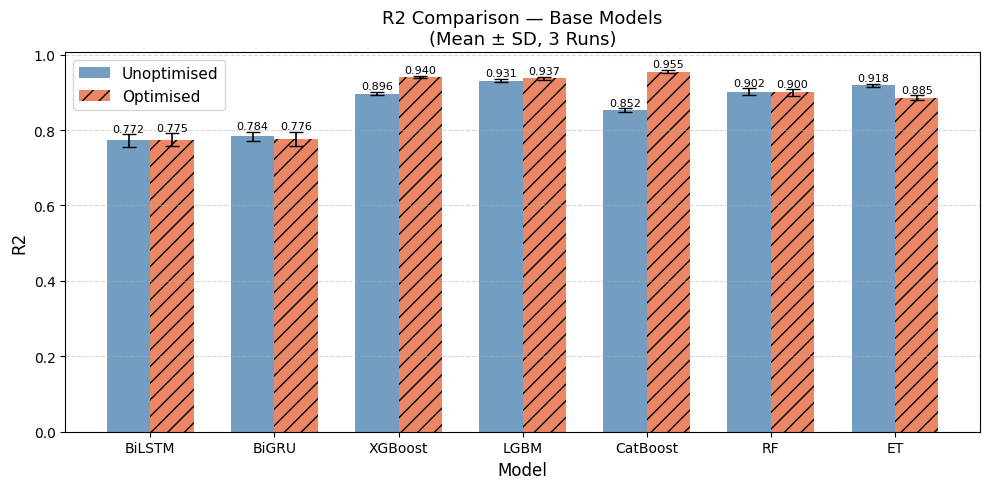

✅ Saved: plot_base_models_R2.png

✅ BLOCK 5 COMPLETE


In [12]:
# =========================================
# 🔧 BLOCK 5: PUBLICATION PLOTS
# Bar charts: Opt vs Unopt per config
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

full_df = pd.read_csv("full_results_all_runs.csv")

def plot_comparison(config_filter, config_label, models, metric="R2", save_name="plot.png"):
    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(models))
    width = 0.35

    for i, (version, color, hatch) in enumerate([
        ("Unoptimised", "#5B8DB8", ""),
        ("Optimised",   "#E8724A", "//"),
    ]):
        means, stds = [], []
        for model in models:
            sub = full_df[
                (full_df["Version"]==version) &
                (full_df["Config"].str.contains(config_filter)) &
                (full_df["Model"]==model)
            ]
            means.append(sub[metric].mean() if len(sub) else 0)
            stds.append(sub[metric].std()   if len(sub) else 0)

        bars = ax.bar(
            x + i * width, means, width,
            yerr=stds, capsize=5,
            color=color, hatch=hatch,
            label=version, alpha=0.85,
            error_kw=dict(elinewidth=1.2, ecolor='black')
        )
        for bar, m, s in zip(bars, means, stds):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + s + 0.002,
                f"{m:.3f}", ha='center', va='bottom', fontsize=8
            )

    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f"{metric} Comparison — {config_label}\n(Mean ± SD, 3 Runs)", fontsize=13)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(models, fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {save_name}")

# Config 1 — Meta-Learners
plot_comparison(
    "Config1", "Config 1: DL + Boosting (Meta-Learners)",
    ["DL_XGB", "DL_LGBM", "DL_CatBoost"],
    metric="R2", save_name="plot_config1_meta_R2.png"
)
plot_comparison(
    "Config1", "Config 1: DL + Boosting (Meta-Learners)",
    ["DL_XGB", "DL_LGBM", "DL_CatBoost"],
    metric="RMSE", save_name="plot_config1_meta_RMSE.png"
)

# Config 2 — Meta-Learners
plot_comparison(
    "Config2", "Config 2: ML Stacking (Meta-Learners)",
    ["Mix_RF", "Mix_ET"],
    metric="R2", save_name="plot_config2_meta_R2.png"
)

# Base Models — both versions
plot_comparison(
    "Both", "Base Models",
    ["BiLSTM", "BiGRU", "XGBoost", "LGBM", "CatBoost", "RF", "ET"],
    metric="R2", save_name="plot_base_models_R2.png"
)

print("\n✅ BLOCK 5 COMPLETE")

In [13]:
# =========================================
# 🔧 BLOCK 6: TCN STANDALONE + FULL RERUN
# TCN Base (Unopt + Opt)
# Config 1: BiLSTM + BiGRU + TCN → XGB/LGBM/CatBoost
# Config 2: BiLSTM + BiGRU + TCN + XGB + LGBM + CatBoost → RF/ET
# Unoptimised & Optimised | 3 Runs each
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import time
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional, Input
from scikeras.wrappers import KerasRegressor
from tcn import TCN

print("✅ All libraries loaded")

# =========================================
# 📂 LOAD DATA
# =========================================
df = pd.read_csv("reduced_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")
target = "Solar_Radiation_(All_Sky)"
leakage_cols = [
    "Solar_Radiation_(Clear_Sky)",
    "Solar_Radiation_(All_Sky)_Lag_1",
    "Solar_Radiation_(All_Sky)_Lag_2",
    "Solar_Radiation_(All_Sky)_Lag_3",
    "Fourier_Transform_Solar_Radiation"
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
X = df.drop(columns=[target])
y = df[target]
print(f"✅ Data ready: {X.shape}")

# =========================================
# 📊 METRICS
# =========================================
def evaluate(y_true, y_pred):
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":  mean_absolute_error(y_true, y_pred),
        "R2":   r2_score(y_true, y_pred),
        "MAPE": mape
    }

# =========================================
# 🧠 DL BUILDERS
# =========================================
def build_bilstm(input_shape):
    m = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def build_bigru(input_shape):
    m = Sequential([
        Input(shape=input_shape),
        Bidirectional(GRU(64, return_sequences=True)),
        Bidirectional(GRU(32)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def build_tcn_unopt(input_shape):
    m = Sequential([
        Input(shape=input_shape),
        TCN(nb_filters=64, kernel_size=3, dropout_rate=0.1,
            dilations=[1, 2, 4, 8], return_sequences=False),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

# =========================================
# 🔧 STEP 1A: TCN UNOPTIMISED BASE MODEL
# =========================================
print("\n" + "="*60)
print("STEP 1A: TCN UNOPTIMISED — STANDALONE BASE MODEL")
print("="*60)

tcn_unopt_records = []

for run in range(3):
    print(f"\n  ▶ Run {run+1}/3")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=run
    )
    scaler = MinMaxScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    X_train_seq = np.expand_dims(X_train_s, axis=1)
    X_test_seq  = np.expand_dims(X_test_s, axis=1)
    INPUT_SHAPE = (X_train_seq.shape[1], X_train_seq.shape[2])

    tcn_model = KerasRegressor(
        model=lambda: build_tcn_unopt(INPUT_SHAPE),
        epochs=5, batch_size=64, verbose=0
    )
    tcn_model.fit(X_train_seq, y_train)
    preds = tcn_model.predict(X_test_seq)

    metrics = evaluate(y_test, preds)
    metrics.update({
        "Version": "Unoptimised", "Run": run+1,
        "Type": "Base", "Model": "TCN", "Config": "Both"
    })
    tcn_unopt_records.append(metrics)
    print(f"  ✅ Run {run+1} R²: {metrics['R2']:.4f}")

tcn_unopt_df = pd.DataFrame(tcn_unopt_records)
print("\n📊 TCN Unoptimised Base — Mean ± SD:")
print(f"  R²:   {tcn_unopt_df['R2'].mean():.4f} ± {tcn_unopt_df['R2'].std():.4f}")
print(f"  RMSE: {tcn_unopt_df['RMSE'].mean():.4f} ± {tcn_unopt_df['RMSE'].std():.4f}")
print(f"  MAE:  {tcn_unopt_df['MAE'].mean():.4f} ± {tcn_unopt_df['MAE'].std():.4f}")
print(f"  MAPE: {tcn_unopt_df['MAPE'].mean():.4f} ± {tcn_unopt_df['MAPE'].std():.4f}")

# =========================================
# 🔧 STEP 1B: TCN OPTUNA TUNING
# =========================================
print("\n" + "="*60)
print("STEP 1B: TCN OPTUNA TUNING (30 TRIALS)")
print("="*60)

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler_opt = MinMaxScaler()
X_train_opt_s = scaler_opt.fit_transform(X_train_opt)
X_train_opt_seq = np.expand_dims(X_train_opt_s, axis=1)
INPUT_SHAPE_OPT = (X_train_opt_seq.shape[1], X_train_opt_seq.shape[2])

def objective_tcn(trial):
    nb_filters     = trial.suggest_categorical("nb_filters",  [32, 64, 128])
    kernel_size    = trial.suggest_categorical("kernel_size", [2, 3, 5])
    dropout_rate   = trial.suggest_float("dropout_rate", 0.0, 0.4)
    dilation_depth = trial.suggest_int("dilation_depth", 2, 5)
    dilations      = [2**i for i in range(dilation_depth)]
    epochs         = trial.suggest_categorical("epochs",     [5, 10])
    batch_size     = trial.suggest_categorical("batch_size", [32, 64])

    def build_tcn_trial():
        m = Sequential([
            Input(shape=INPUT_SHAPE_OPT),
            TCN(nb_filters=nb_filters, kernel_size=kernel_size,
                dropout_rate=dropout_rate, dilations=dilations,
                return_sequences=False),
            Dense(1)
        ])
        m.compile(optimizer='adam', loss='mse')
        return m

    try:
        tcn_t = KerasRegressor(
            model=build_tcn_trial,
            epochs=epochs, batch_size=batch_size, verbose=0
        )
        tcn_t.fit(X_train_opt_seq, y_train_opt)
        X_test_opt_s   = scaler_opt.transform(X_test_opt)
        X_test_opt_seq = np.expand_dims(X_test_opt_s, axis=1)
        preds = tcn_t.predict(X_test_opt_seq)
        return r2_score(y_test_opt, preds)
    except Exception as e:
        print(f"  ⚠️ Trial failed: {e}")
        return 0.0

study_tcn = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_tcn.optimize(objective_tcn, n_trials=30, show_progress_bar=True)

best_tcn_params   = study_tcn.best_params
best_tcn_dilations = [2**i for i in range(best_tcn_params["dilation_depth"])]

print(f"\n✅ Best TCN R² (Optuna): {study_tcn.best_value:.4f}")
print(f"   Best Params: {best_tcn_params}")
print(f"   Dilations:   {best_tcn_dilations}")

# =========================================
# 🔧 STEP 1C: TCN OPTIMISED BASE MODEL
# =========================================
print("\n" + "="*60)
print("STEP 1C: TCN OPTIMISED — STANDALONE BASE MODEL")
print("="*60)

def build_tcn_opt(input_shape):
    m = Sequential([
        Input(shape=input_shape),
        TCN(
            nb_filters=best_tcn_params["nb_filters"],
            kernel_size=best_tcn_params["kernel_size"],
            dropout_rate=best_tcn_params["dropout_rate"],
            dilations=best_tcn_dilations,
            return_sequences=False
        ),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

tcn_opt_records = []

for run in range(3):
    print(f"\n  ▶ Run {run+1}/3")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=run
    )
    scaler = MinMaxScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    X_train_seq = np.expand_dims(X_train_s, axis=1)
    X_test_seq  = np.expand_dims(X_test_s, axis=1)
    INPUT_SHAPE = (X_train_seq.shape[1], X_train_seq.shape[2])

    tcn_model = KerasRegressor(
        model=lambda: build_tcn_opt(INPUT_SHAPE),
        epochs=best_tcn_params["epochs"],
        batch_size=best_tcn_params["batch_size"],
        verbose=0
    )
    tcn_model.fit(X_train_seq, y_train)
    preds = tcn_model.predict(X_test_seq)

    metrics = evaluate(y_test, preds)
    metrics.update({
        "Version": "Optimised", "Run": run+1,
        "Type": "Base", "Model": "TCN", "Config": "Both"
    })
    tcn_opt_records.append(metrics)
    print(f"  ✅ Run {run+1} R²: {metrics['R2']:.4f}")

tcn_opt_df = pd.DataFrame(tcn_opt_records)
print("\n📊 TCN Optimised Base — Mean ± SD:")
print(f"  R²:   {tcn_opt_df['R2'].mean():.4f} ± {tcn_opt_df['R2'].std():.4f}")
print(f"  RMSE: {tcn_opt_df['RMSE'].mean():.4f} ± {tcn_opt_df['RMSE'].std():.4f}")
print(f"  MAE:  {tcn_opt_df['MAE'].mean():.4f} ± {tcn_opt_df['MAE'].std():.4f}")
print(f"  MAPE: {tcn_opt_df['MAPE'].mean():.4f} ± {tcn_opt_df['MAPE'].std():.4f}")

# =========================================
# 🔧 STEP 2: FULL CONFIG 1 & 2 RERUN
# =========================================
print("\n" + "="*60)
print("STEP 2: CONFIG 1 & 2 RERUN WITH TCN + FIXED CONFIG 2")
print("="*60)

# ---- Param sets from Block 1 ----
UNOPT = {
    "XGB":  dict(n_estimators=200, learning_rate=0.05, max_depth=5, n_jobs=-1),
    "LGBM": dict(n_estimators=200, learning_rate=0.05, verbose=-1),
    "CAT":  dict(iterations=200,   learning_rate=0.05, verbose=0, random_state=42),
    "RF":   dict(n_estimators=200, random_state=42, n_jobs=-1),
    "ET":   dict(n_estimators=200, random_state=42, n_jobs=-1),
}

OPT = {
    "XGB":  {**best_xgb_params,  "n_jobs": -1},
    "LGBM": {**best_lgbm_params, "verbose": -1},
    "CAT":  {**best_cat_params,  "verbose": 0, "random_state": 42},
    "RF":   {**best_rf_params,   "random_state": 42, "n_jobs": -1},
    "ET":   {**best_et_params,   "random_state": 42, "n_jobs": -1},
}

# Fix CatBoost key
for p in [UNOPT, OPT]:
    if "n_estimators" in p["CAT"]:
        p["CAT"]["iterations"] = p["CAT"].pop("n_estimators")

new_records = []

for version, params in [("Unoptimised", UNOPT), ("Optimised", OPT)]:
    print(f"\n{'='*50}")
    print(f"🚀 VERSION: {version}")
    print(f"{'='*50}")

    for run in range(3):
        print(f"\n  ▶ Run {run+1}/3")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=run
        )

        scaler = MinMaxScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)
        X_train_seq = np.expand_dims(X_train_s, axis=1)
        X_test_seq  = np.expand_dims(X_test_s, axis=1)
        INPUT_SHAPE = (X_train_seq.shape[1], X_train_seq.shape[2])

        # ---- Train 3 DL base models ----
        bilstm = KerasRegressor(
            model=lambda: build_bilstm(INPUT_SHAPE),
            epochs=5, batch_size=64, verbose=0
        )
        bigru = KerasRegressor(
            model=lambda: build_bigru(INPUT_SHAPE),
            epochs=5, batch_size=64, verbose=0
        )
        if version == "Unoptimised":
            tcn = KerasRegressor(
                model=lambda: build_tcn_unopt(INPUT_SHAPE),
                epochs=5, batch_size=64, verbose=0
            )
        else:
            tcn = KerasRegressor(
                model=lambda: build_tcn_opt(INPUT_SHAPE),
                epochs=best_tcn_params["epochs"],
                batch_size=best_tcn_params["batch_size"],
                verbose=0
            )

        print("    Training BiLSTM...")
        bilstm.fit(X_train_seq, y_train)
        print("    Training BiGRU...")
        bigru.fit(X_train_seq, y_train)
        print("    Training TCN...")
        tcn.fit(X_train_seq, y_train)

        # ================================================
        # CONFIG 1: BiLSTM + BiGRU + TCN → XGB/LGBM/CatBoost
        # Meta-feature = raw features + 3 DL predictions
        # ================================================
        X_train_h = X_train.copy()
        X_test_h  = X_test.copy()

        X_train_h["bilstm"] = bilstm.predict(X_train_seq)
        X_train_h["bigru"]  = bigru.predict(X_train_seq)
        X_train_h["tcn"]    = tcn.predict(X_train_seq)

        X_test_h["bilstm"]  = bilstm.predict(X_test_seq)
        X_test_h["bigru"]   = bigru.predict(X_test_seq)
        X_test_h["tcn"]     = tcn.predict(X_test_seq)

        for name, cls, p in [
            ("DL_XGB",      XGBRegressor,      params["XGB"]),
            ("DL_LGBM",     LGBMRegressor,     params["LGBM"]),
            ("DL_CatBoost", CatBoostRegressor, params["CAT"]),
        ]:
            m = cls(**p)
            m.fit(X_train_h, y_train)
            preds = m.predict(X_test_h)

            metrics = evaluate(y_test, preds)
            metrics.update({
                "Version": version, "Run": run+1,
                "Type": "MetaLearner", "Model": name,
                "Config": "Config1_DL_Boosting_TCN"
            })
            new_records.append(metrics)
            print(f"    ✅ {name} done")

        # ================================================
        # CONFIG 2: BiLSTM + BiGRU + TCN + XGB + LGBM + CatBoost → RF/ET
        # All 6 as proper base learners — manual stacking surface
        # ================================================

        # Step 1: Train ML base learners on raw features
        xgb_base  = XGBRegressor(**params["XGB"])
        lgbm_base = LGBMRegressor(**params["LGBM"])
        cat_base  = CatBoostRegressor(**params["CAT"])

        xgb_base.fit(X_train, y_train)
        lgbm_base.fit(X_train, y_train)
        cat_base.fit(X_train, y_train)

        # Step 2: Build meta-feature surface
        # raw features + 3 DL predictions + 3 ML predictions
        X_train_meta = X_train.copy()
        X_test_meta  = X_test.copy()

        # DL base predictions
        X_train_meta["bilstm"]    = bilstm.predict(X_train_seq)
        X_train_meta["bigru"]     = bigru.predict(X_train_seq)
        X_train_meta["tcn"]       = tcn.predict(X_train_seq)

        # ML base predictions
        X_train_meta["xgb_base"]  = xgb_base.predict(X_train)
        X_train_meta["lgbm_base"] = lgbm_base.predict(X_train)
        X_train_meta["cat_base"]  = cat_base.predict(X_train)

        # DL predictions on test
        X_test_meta["bilstm"]     = bilstm.predict(X_test_seq)
        X_test_meta["bigru"]      = bigru.predict(X_test_seq)
        X_test_meta["tcn"]        = tcn.predict(X_test_seq)

        # ML predictions on test
        X_test_meta["xgb_base"]   = xgb_base.predict(X_test)
        X_test_meta["lgbm_base"]  = lgbm_base.predict(X_test)
        X_test_meta["cat_base"]   = cat_base.predict(X_test)

        # Step 3: Train RF and ET meta-learners
        for name, meta_cls, p in [
            ("Mix_RF", RandomForestRegressor, params["RF"]),
            ("Mix_ET", ExtraTreesRegressor,   params["ET"]),
        ]:
            meta_model = meta_cls(**p)
            meta_model.fit(X_train_meta, y_train)
            preds = meta_model.predict(X_test_meta)

            metrics = evaluate(y_test, preds)
            metrics.update({
                "Version": version, "Run": run+1,
                "Type": "MetaLearner", "Model": name,
                "Config": "Config2_ML_Stacking_TCN"
            })
            new_records.append(metrics)
            print(f"    ✅ {name} done")

        print(f"  ✅ Run {run+1} complete")

# =========================================
# 📊 COMPILE & SAVE RESULTS
# =========================================
print("\n📊 Compiling all new results...")

new_df  = pd.DataFrame(new_records)

all_new = pd.concat([tcn_unopt_df, tcn_opt_df, new_df], ignore_index=True)

try:
    old_df      = pd.read_csv("full_results_all_runs.csv")
    combined_df = pd.concat([old_df, all_new], ignore_index=True)
    print(f"✅ Appended to existing results. Total rows: {len(combined_df)}")
except FileNotFoundError:
    combined_df = all_new
    print("⚠️ No existing file — saving new results only.")

combined_df.to_csv("full_results_all_runs_v2.csv", index=False)
print("✅ Saved: full_results_all_runs_v2.csv")

# =========================================
# 📋 FINAL SUMMARY TABLES
# =========================================
def fmt(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

summary = combined_df.groupby(["Version","Config","Type","Model"]).agg(
    R2_mean=("R2","mean"),     R2_std=("R2","std"),
    RMSE_mean=("RMSE","mean"), RMSE_std=("RMSE","std"),
    MAE_mean=("MAE","mean"),   MAE_std=("MAE","std"),
    MAPE_mean=("MAPE","mean"), MAPE_std=("MAPE","std"),
).reset_index()

summary["R²"]   = summary.apply(lambda r: fmt(r.R2_mean,   r.R2_std),   axis=1)
summary["RMSE"] = summary.apply(lambda r: fmt(r.RMSE_mean, r.RMSE_std), axis=1)
summary["MAE"]  = summary.apply(lambda r: fmt(r.MAE_mean,  r.MAE_std),  axis=1)
summary["MAPE"] = summary.apply(lambda r: fmt(r.MAPE_mean, r.MAPE_std), axis=1)

display_cols = ["Version","Config","Type","Model","R²","RMSE","MAE","MAPE"]

# ---- TABLE 1: BASE MODELS ----
print("\n")
print("="*90)
print("📊 TABLE 7.1 — BASE MODELS UNOPTIMISED (Mean ± SD, 3 Runs)")
print("="*90)
base_unopt = summary[
    (summary["Type"]=="Base") &
    (summary["Version"]=="Unoptimised")
][display_cols]
print(base_unopt.to_string(index=False))

print("\n")
print("="*90)
print("📊 TABLE 7.2 — BASE MODELS OPTIMISED via Optuna (Mean ± SD, 3 Runs)")
print("="*90)
base_opt = summary[
    (summary["Type"]=="Base") &
    (summary["Version"]=="Optimised")
][display_cols]
print(base_opt.to_string(index=False))

# ---- TABLE 2: CONFIG 1 ----
print("\n")
print("="*90)
print("📊 TABLE 7.3 — CONFIG 1: DL_XGB, DL_LGBM, DL_CatBoost")
print("      Base: BiLSTM + BiGRU + TCN | Meta: XGB / LGBM / CatBoost")
print("="*90)
c1_unopt = summary[
    (summary["Type"]=="MetaLearner") &
    (summary["Config"].str.contains("Config1")) &
    (summary["Version"]=="Unoptimised")
][display_cols]
print("--- Unoptimised ---")
print(c1_unopt.to_string(index=False))

c1_opt = summary[
    (summary["Type"]=="MetaLearner") &
    (summary["Config"].str.contains("Config1")) &
    (summary["Version"]=="Optimised")
][display_cols]
print("\n--- Optimised ---")
print(c1_opt.to_string(index=False))

# ---- TABLE 3: CONFIG 2 ----
print("\n")
print("="*90)
print("📊 TABLE 7.4 — CONFIG 2: Mix_RF, Mix_ET")
print("      Base: BiLSTM + BiGRU + TCN + XGB + LGBM + CatBoost | Meta: RF / ET")
print("="*90)
c2_unopt = summary[
    (summary["Type"]=="MetaLearner") &
    (summary["Config"].str.contains("Config2")) &
    (summary["Version"]=="Unoptimised")
][display_cols]
print("--- Unoptimised ---")
print(c2_unopt.to_string(index=False))

c2_opt = summary[
    (summary["Type"]=="MetaLearner") &
    (summary["Config"].str.contains("Config2")) &
    (summary["Version"]=="Optimised")
][display_cols]
print("\n--- Optimised ---")
print(c2_opt.to_string(index=False))

# ---- TABLE 4: FULL UNIFIED RANKING (Optimised meta-learners only) ----
print("\n")
print("="*90)
print("📊 TABLE 7.5 — UNIFIED RANKING: ALL 5 META-LEARNERS OPTIMISED")
print("="*90)
all_opt_meta = summary[
    (summary["Type"]=="MetaLearner") &
    (summary["Version"]=="Optimised")
].copy()
all_opt_meta = all_opt_meta.sort_values("R2_mean", ascending=False)
print(all_opt_meta[display_cols].to_string(index=False))

summary.to_csv("block6_full_summary.csv", index=False)
print("\n✅ Full summary saved: block6_full_summary.csv")
print("\n✅ BLOCK 6 COMPLETE")

✅ All libraries loaded
✅ Data ready: (24913, 19)

STEP 1A: TCN UNOPTIMISED — STANDALONE BASE MODEL

  ▶ Run 1/3

  ✅ Run 1 R²: 0.7996

  ▶ Run 2/3
  ✅ Run 2 R²: 0.8031

  ▶ Run 3/3
  ✅ Run 3 R²: 0.7649

📊 TCN Unoptimised Base — Mean ± SD:
  R²:   0.7892 ± 0.0211
  RMSE: 0.0762 ± 0.0030
  MAE:  0.0435 ± 0.0050
  MAPE: 6.1475 ± 0.6589

STEP 1B: TCN OPTUNA TUNING (30 TRIALS)


Best trial: 15. Best value: 0.858354: 100%|██████████| 30/30 [33:12<00:00, 66.42s/it]



✅ Best TCN R² (Optuna): 0.8584
   Best Params: {'nb_filters': 128, 'kernel_size': 3, 'dropout_rate': 0.0102197979242174, 'dilation_depth': 4, 'epochs': 10, 'batch_size': 64}
   Dilations:   [1, 2, 4, 8]

STEP 1C: TCN OPTIMISED — STANDALONE BASE MODEL

  ▶ Run 1/3
  ✅ Run 1 R²: 0.8469

  ▶ Run 2/3
  ✅ Run 2 R²: 0.8563

  ▶ Run 3/3
  ✅ Run 3 R²: 0.8519

📊 TCN Optimised Base — Mean ± SD:
  R²:   0.8517 ± 0.0047
  RMSE: 0.0640 ± 0.0012
  MAE:  0.0322 ± 0.0023
  MAPE: 4.5734 ± 0.4624

STEP 2: CONFIG 1 & 2 RERUN WITH TCN + FIXED CONFIG 2

🚀 VERSION: Unoptimised

  ▶ Run 1/3
    Training BiLSTM...
    Training BiGRU...
    Training TCN...
    ✅ DL_XGB done
    ✅ DL_LGBM done
    ✅ DL_CatBoost done
    ✅ Mix_RF done
    ✅ Mix_ET done
  ✅ Run 1 complete

  ▶ Run 2/3
    Training BiLSTM...
    Training BiGRU...
    Training TCN...
    ✅ DL_XGB done
    ✅ DL_LGBM done
    ✅ DL_CatBoost done
    ✅ Mix_RF done
    ✅ Mix_ET done
  ✅ Run 2 complete

  ▶ Run 3/3
    Training BiLSTM...
    Training Bi

✅ Libraries loaded
✅ Data ready: (24913, 19)

⏳ Training BiLSTM...
⏳ Training BiGRU...
⏳ Training TCN (Optimised)...
✅ Config 1 feature matrix: (19930, 22)

⏳ Training ML base learners for Config 2...
✅ Config 2 feature matrix: (19930, 25)

🚀 CONFIG 1: Training DL_XGB (Optimised)...

🔍 SHAP Analysis: DL_XGB
  ✅ SHAP values computed: (4983, 22)


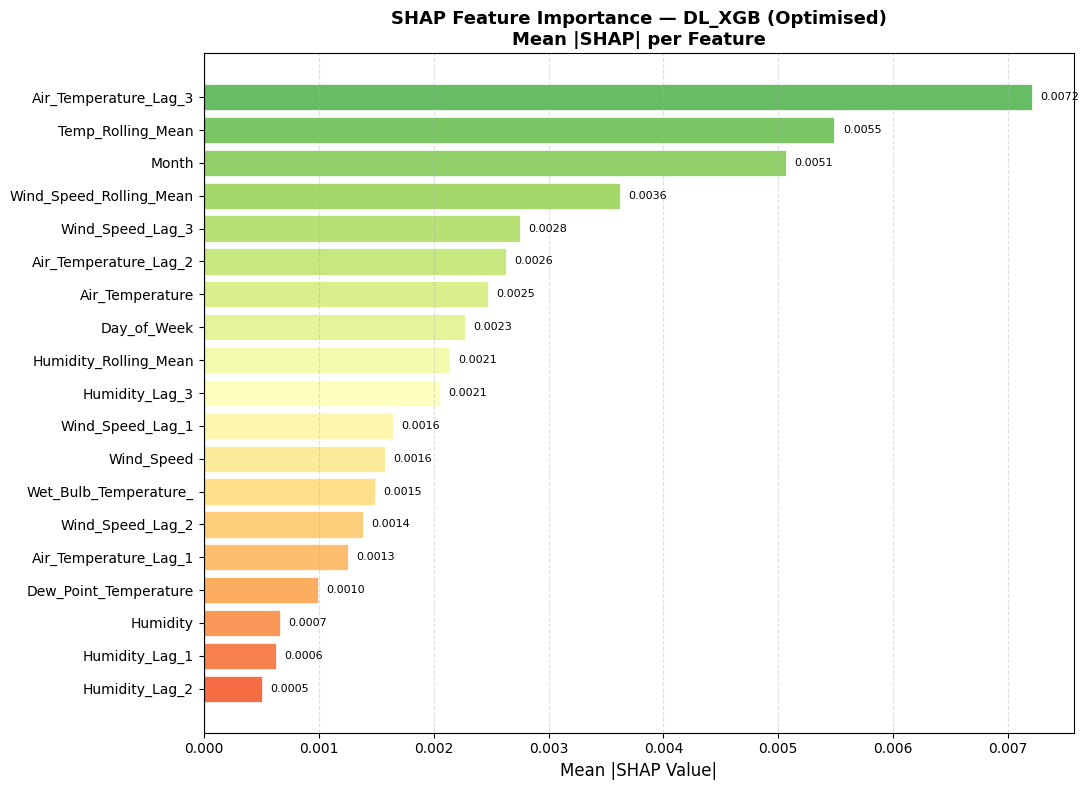

  ✅ Saved: shap_dl_xgb_shap_bar.png


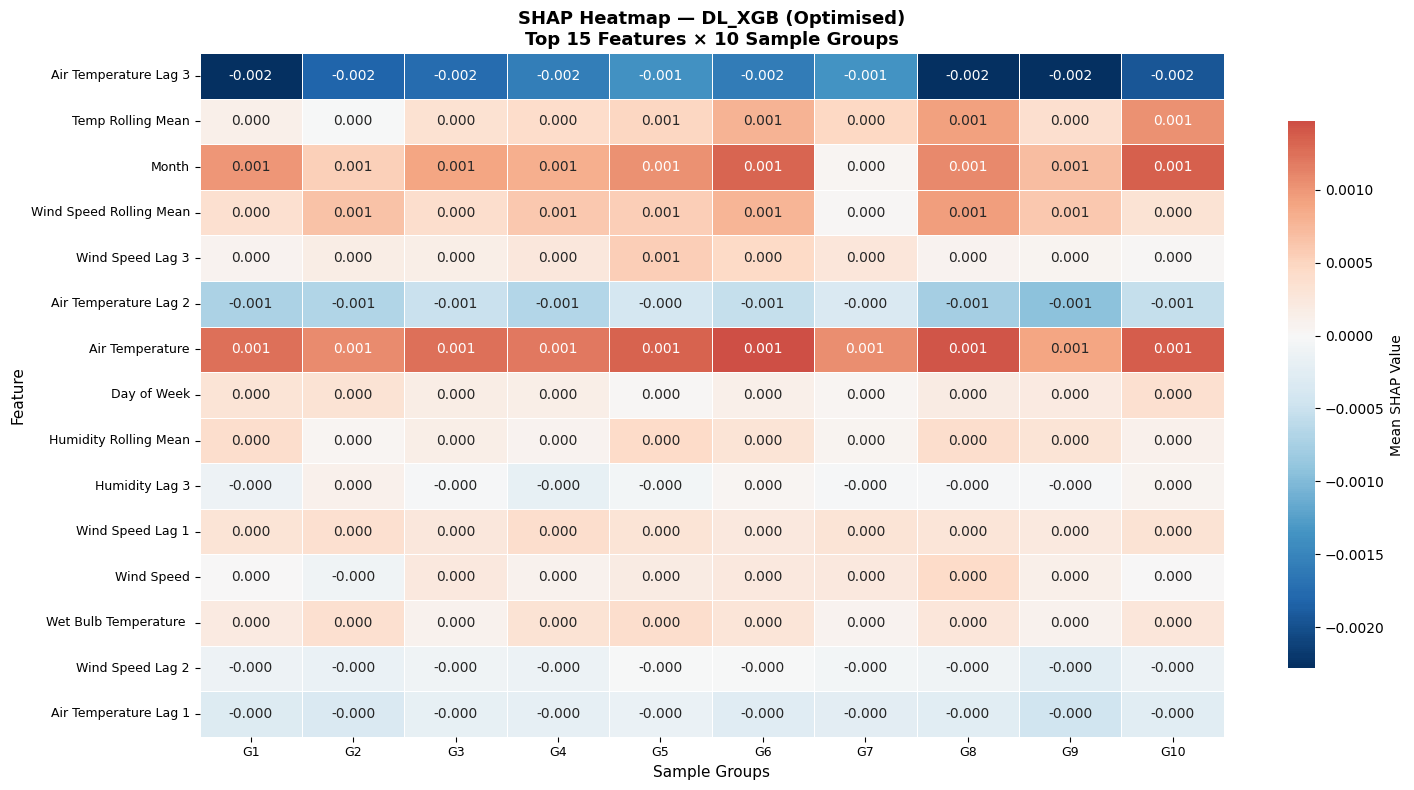

  ✅ Saved: shap_dl_xgb_shap_heatmap.png

  📋 Mean |SHAP| Table — DL_XGB:
 Rank                 Feature  Mean |SHAP|
    1   Air_Temperature_Lag_3     0.007210
    2       Temp_Rolling_Mean     0.005489
    3                   Month     0.005067
    4 Wind_Speed_Rolling_Mean     0.003621
    5        Wind_Speed_Lag_3     0.002754
    6   Air_Temperature_Lag_2     0.002629
    7         Air_Temperature     0.002472
    8             Day_of_Week     0.002270
    9   Humidity_Rolling_Mean     0.002138
   10          Humidity_Lag_3     0.002051
   11        Wind_Speed_Lag_1     0.001644
   12              Wind_Speed     0.001580
   13   Wet_Bulb_Temperature_     0.001488
   14        Wind_Speed_Lag_2     0.001381
   15   Air_Temperature_Lag_1     0.001255
   16   Dew_Point_Temperature     0.000997
   17                Humidity     0.000663
   18          Humidity_Lag_1     0.000624
   19          Humidity_Lag_2     0.000509
  ✅ Table saved: shap_dl_xgb_shap_table.csv

🚀 CONFIG 1: Training D

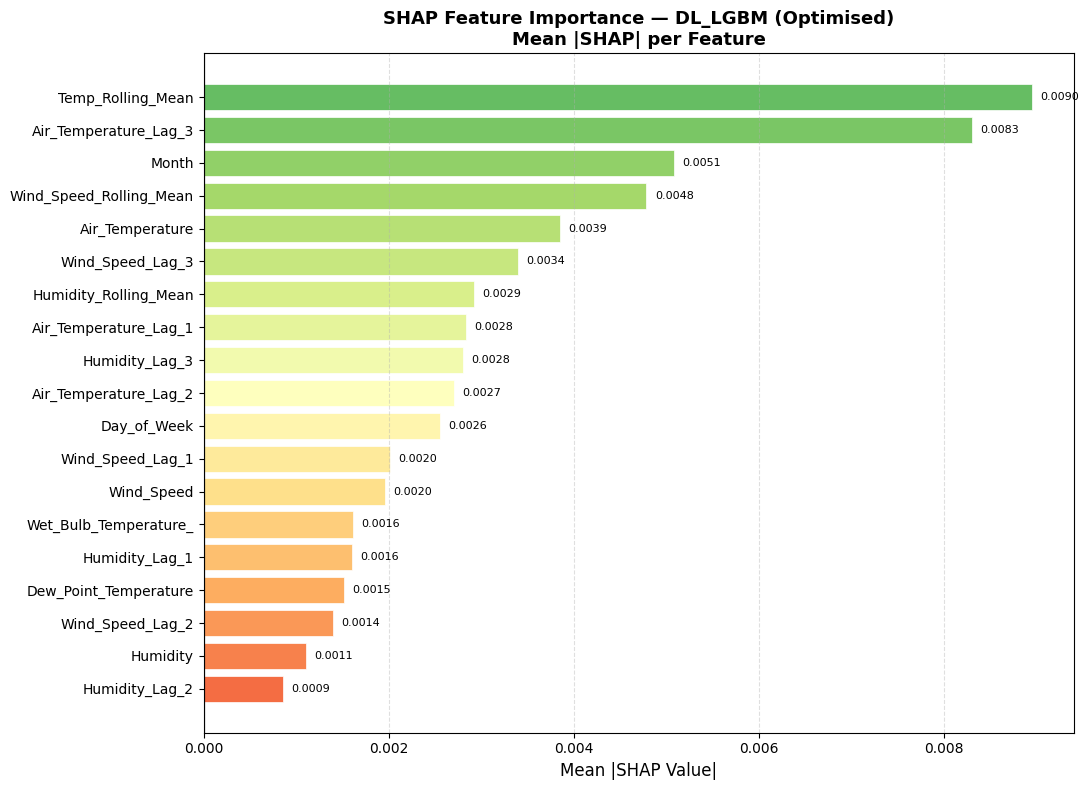

  ✅ Saved: shap_dl_lgbm_shap_bar.png


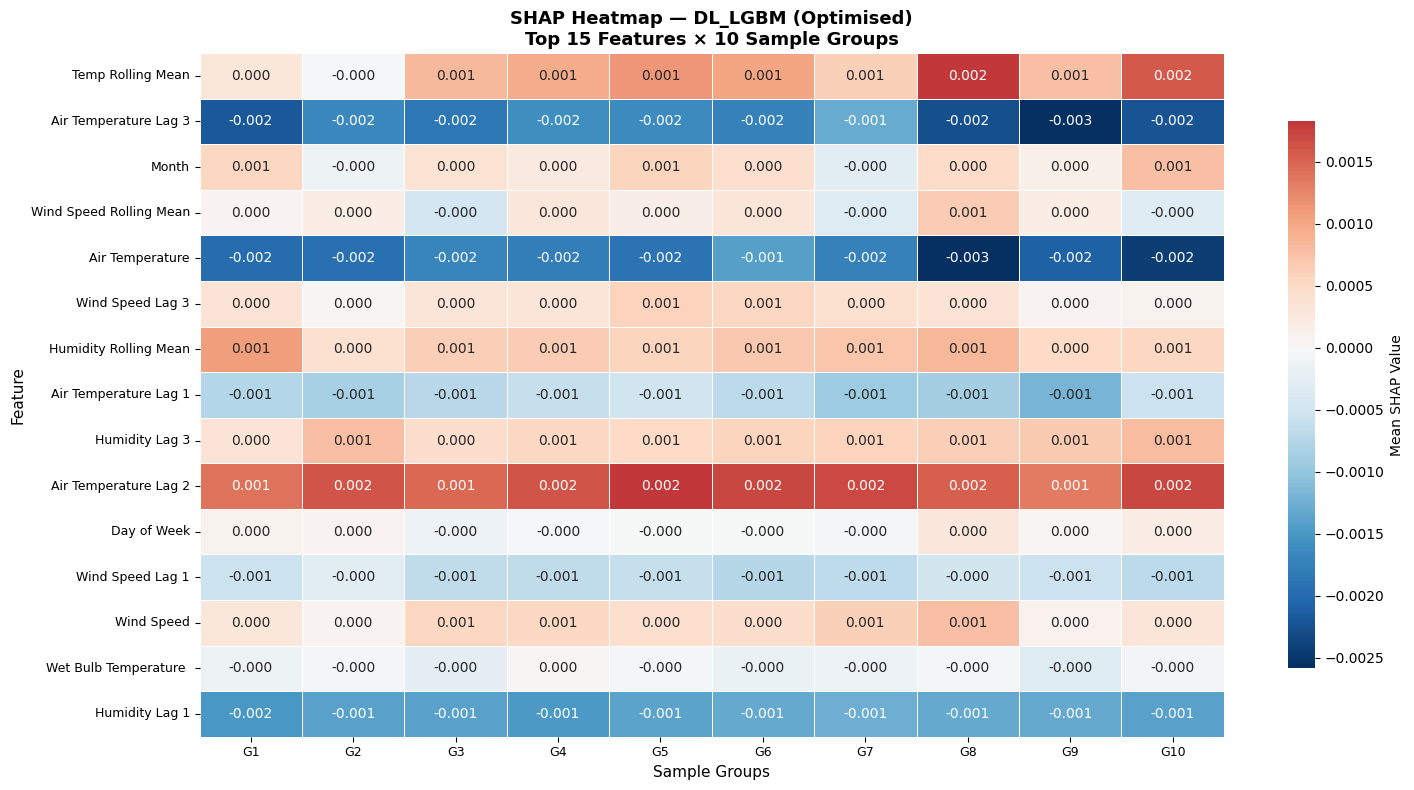

  ✅ Saved: shap_dl_lgbm_shap_heatmap.png

  📋 Mean |SHAP| Table — DL_LGBM:
 Rank                 Feature  Mean |SHAP|
    1       Temp_Rolling_Mean     0.008951
    2   Air_Temperature_Lag_3     0.008304
    3                   Month     0.005077
    4 Wind_Speed_Rolling_Mean     0.004782
    5         Air_Temperature     0.003852
    6        Wind_Speed_Lag_3     0.003395
    7   Humidity_Rolling_Mean     0.002923
    8   Air_Temperature_Lag_1     0.002831
    9          Humidity_Lag_3     0.002795
   10   Air_Temperature_Lag_2     0.002704
   11             Day_of_Week     0.002554
   12        Wind_Speed_Lag_1     0.002009
   13              Wind_Speed     0.001957
   14   Wet_Bulb_Temperature_     0.001612
   15          Humidity_Lag_1     0.001597
   16   Dew_Point_Temperature     0.001510
   17        Wind_Speed_Lag_2     0.001398
   18                Humidity     0.001107
   19          Humidity_Lag_2     0.000857
  ✅ Table saved: shap_dl_lgbm_shap_table.csv

🚀 CONFIG 1: Trainin

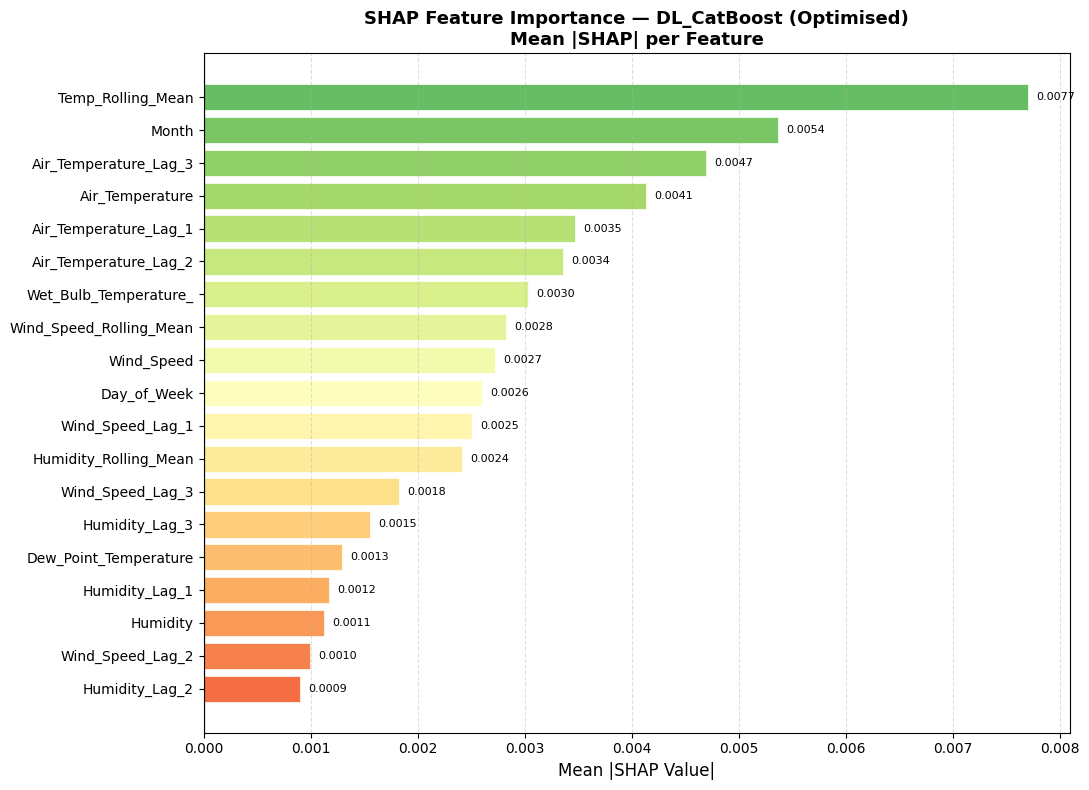

  ✅ Saved: shap_dl_catboost_shap_bar.png


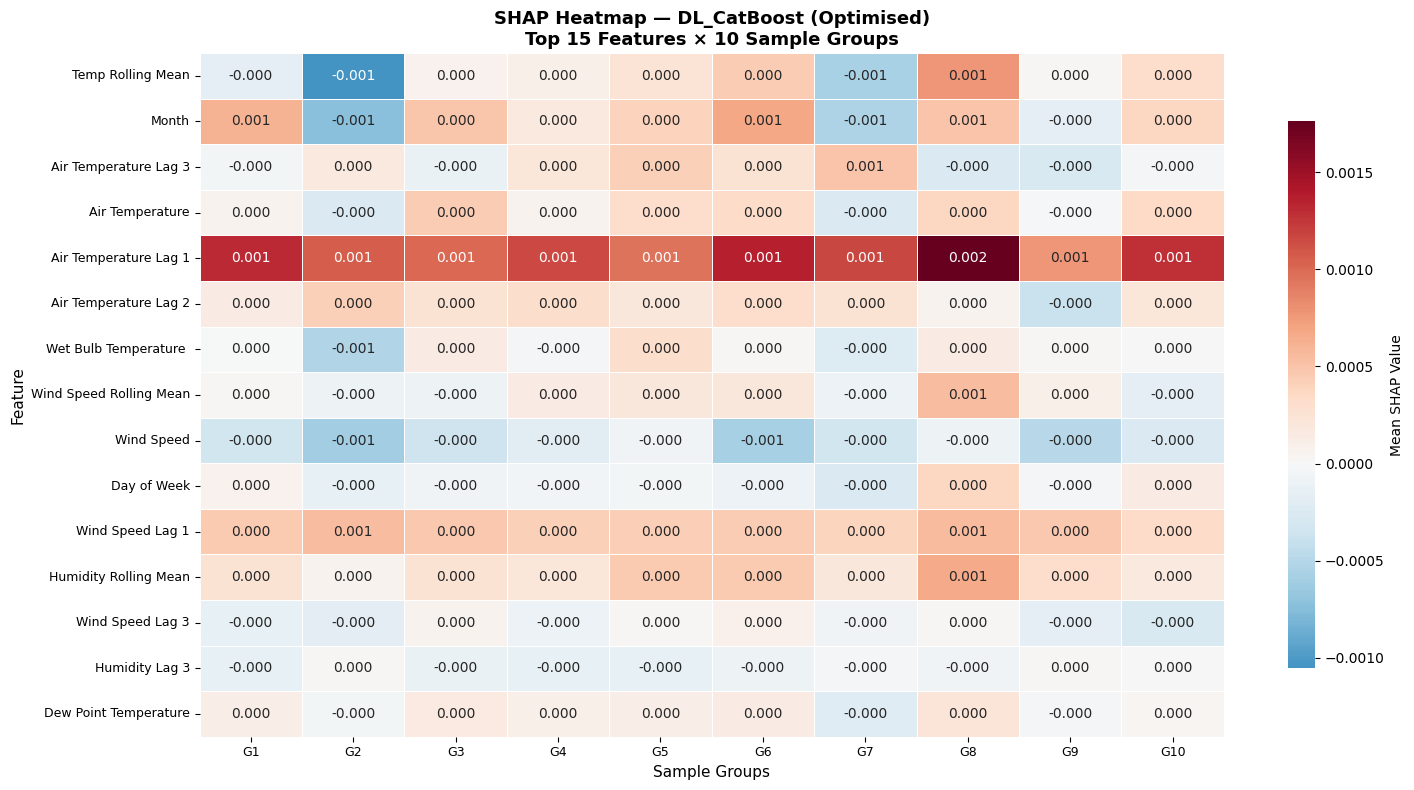

  ✅ Saved: shap_dl_catboost_shap_heatmap.png

  📋 Mean |SHAP| Table — DL_CatBoost:
 Rank                 Feature  Mean |SHAP|
    1       Temp_Rolling_Mean     0.007704
    2                   Month     0.005366
    3   Air_Temperature_Lag_3     0.004694
    4         Air_Temperature     0.004132
    5   Air_Temperature_Lag_1     0.003469
    6   Air_Temperature_Lag_2     0.003351
    7   Wet_Bulb_Temperature_     0.003032
    8 Wind_Speed_Rolling_Mean     0.002827
    9              Wind_Speed     0.002716
   10             Day_of_Week     0.002601
   11        Wind_Speed_Lag_1     0.002508
   12   Humidity_Rolling_Mean     0.002413
   13        Wind_Speed_Lag_3     0.001824
   14          Humidity_Lag_3     0.001549
   15   Dew_Point_Temperature     0.001288
   16          Humidity_Lag_1     0.001172
   17                Humidity     0.001123
   18        Wind_Speed_Lag_2     0.000994
   19          Humidity_Lag_2     0.000895
  ✅ Table saved: shap_dl_catboost_shap_table.csv

🚀 CONFI

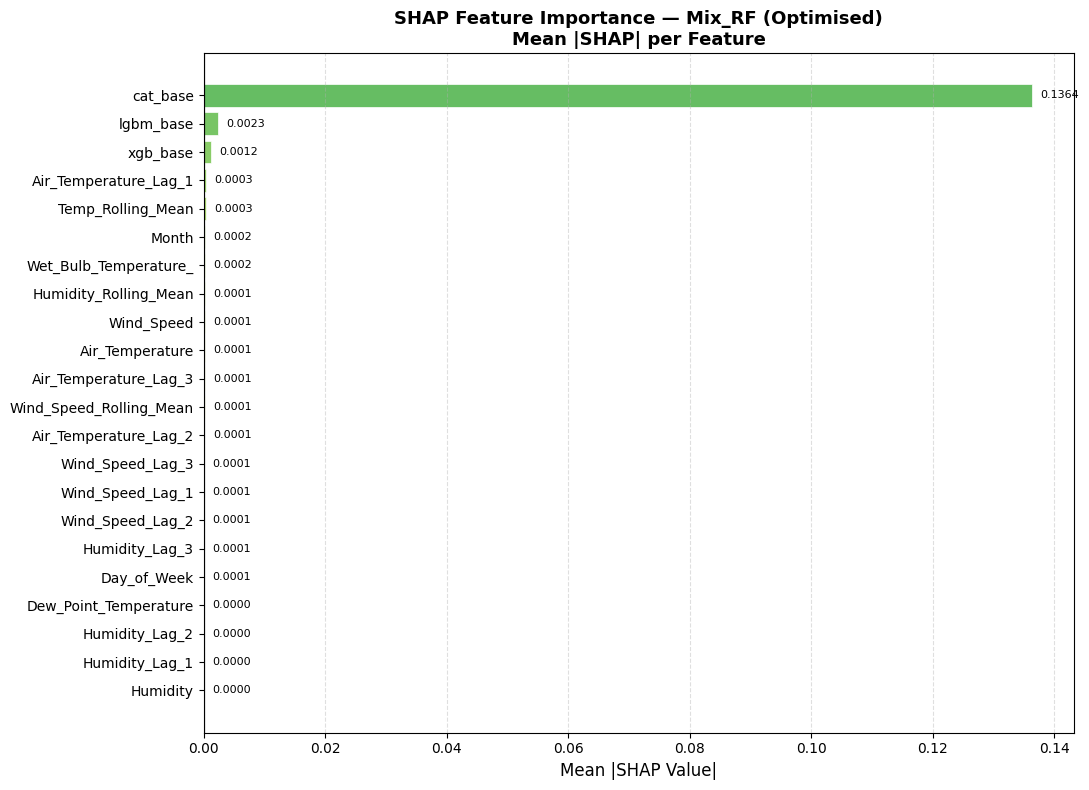

  ✅ Saved: shap_mix_rf_shap_bar.png


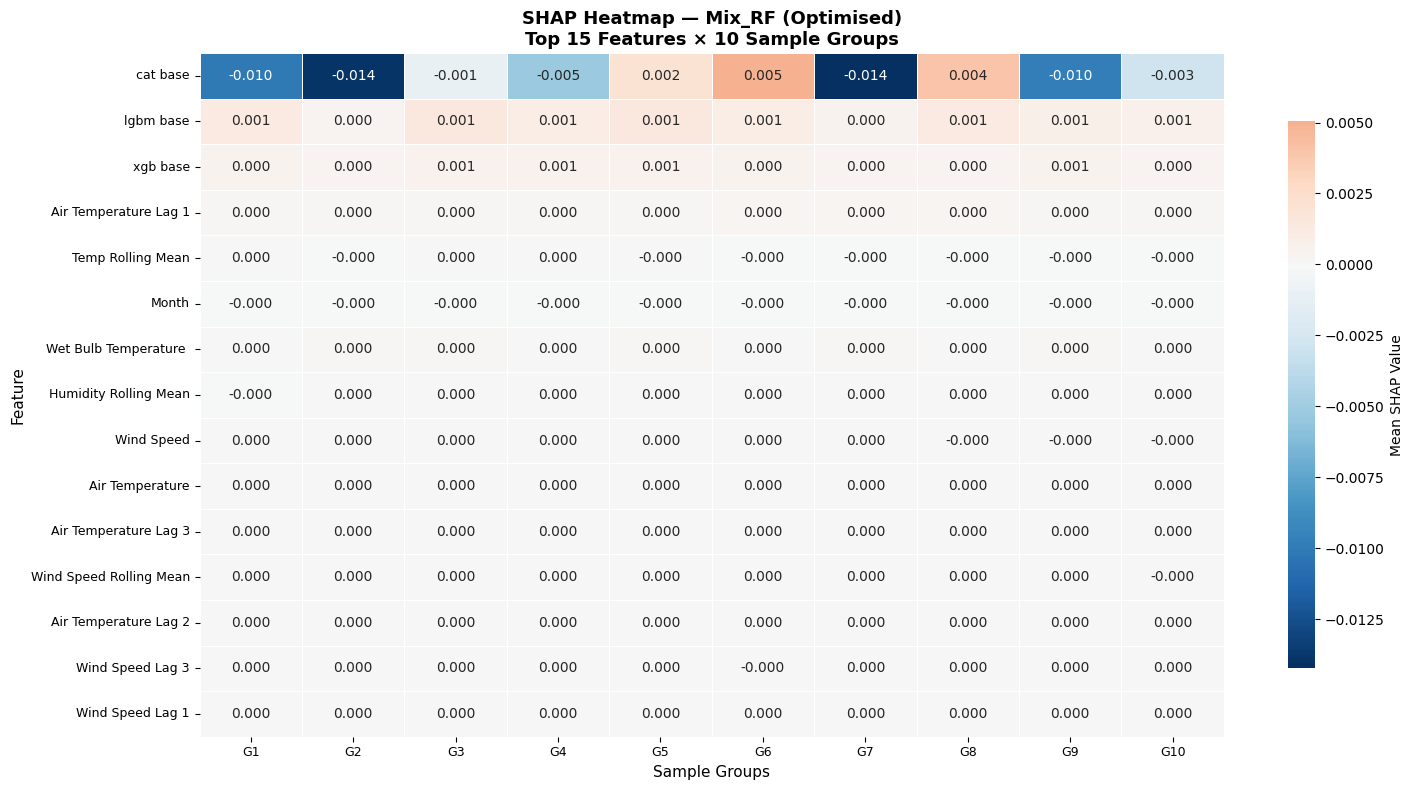

  ✅ Saved: shap_mix_rf_shap_heatmap.png

  📋 Mean |SHAP| Table — Mix_RF:
 Rank                 Feature  Mean |SHAP|
    1                cat_base     0.136354
    2               lgbm_base     0.002283
    3                xgb_base     0.001158
    4   Air_Temperature_Lag_1     0.000344
    5       Temp_Rolling_Mean     0.000304
    6                   Month     0.000216
    7   Wet_Bulb_Temperature_     0.000180
    8   Humidity_Rolling_Mean     0.000128
    9              Wind_Speed     0.000126
   10         Air_Temperature     0.000124
   11   Air_Temperature_Lag_3     0.000124
   12 Wind_Speed_Rolling_Mean     0.000123
   13   Air_Temperature_Lag_2     0.000102
   14        Wind_Speed_Lag_3     0.000087
   15        Wind_Speed_Lag_1     0.000086
   16        Wind_Speed_Lag_2     0.000080
   17          Humidity_Lag_3     0.000063
   18             Day_of_Week     0.000055
   19   Dew_Point_Temperature     0.000048
   20          Humidity_Lag_2     0.000048
   21          Humidity_

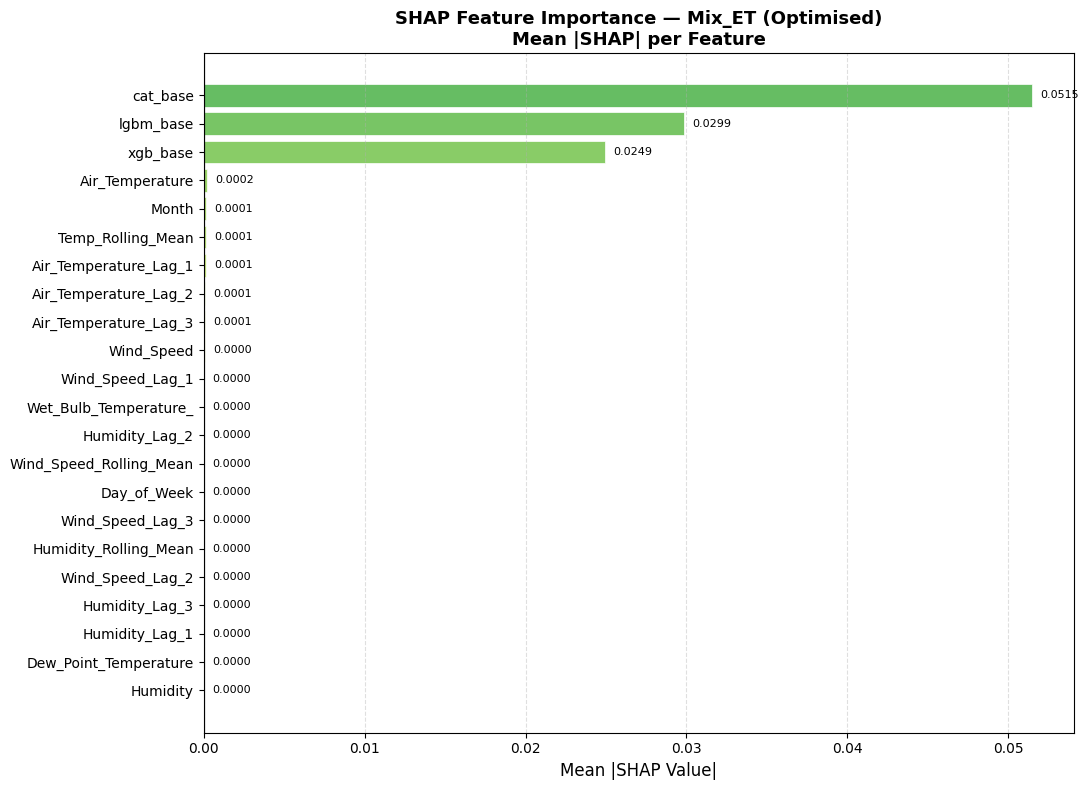

  ✅ Saved: shap_mix_et_shap_bar.png


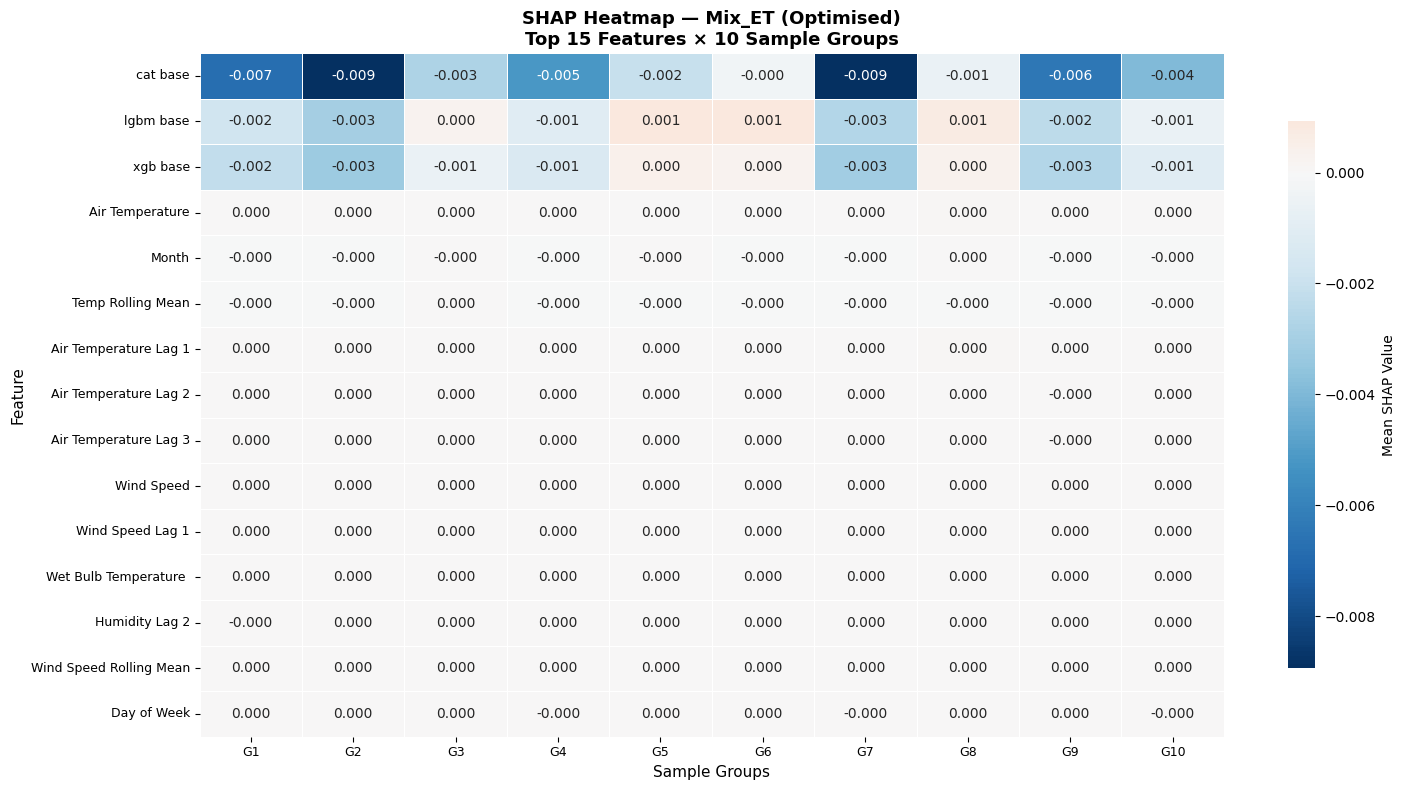

  ✅ Saved: shap_mix_et_shap_heatmap.png

  📋 Mean |SHAP| Table — Mix_ET:
 Rank                 Feature  Mean |SHAP|
    1                cat_base     0.051511
    2               lgbm_base     0.029858
    3                xgb_base     0.024947
    4         Air_Temperature     0.000170
    5                   Month     0.000135
    6       Temp_Rolling_Mean     0.000114
    7   Air_Temperature_Lag_1     0.000107
    8   Air_Temperature_Lag_2     0.000072
    9   Air_Temperature_Lag_3     0.000069
   10              Wind_Speed     0.000047
   11        Wind_Speed_Lag_1     0.000037
   12   Wet_Bulb_Temperature_     0.000036
   13          Humidity_Lag_2     0.000034
   14 Wind_Speed_Rolling_Mean     0.000034
   15             Day_of_Week     0.000033
   16        Wind_Speed_Lag_3     0.000033
   17   Humidity_Rolling_Mean     0.000031
   18        Wind_Speed_Lag_2     0.000031
   19          Humidity_Lag_3     0.000030
   20          Humidity_Lag_1     0.000028
   21   Dew_Point_Temper

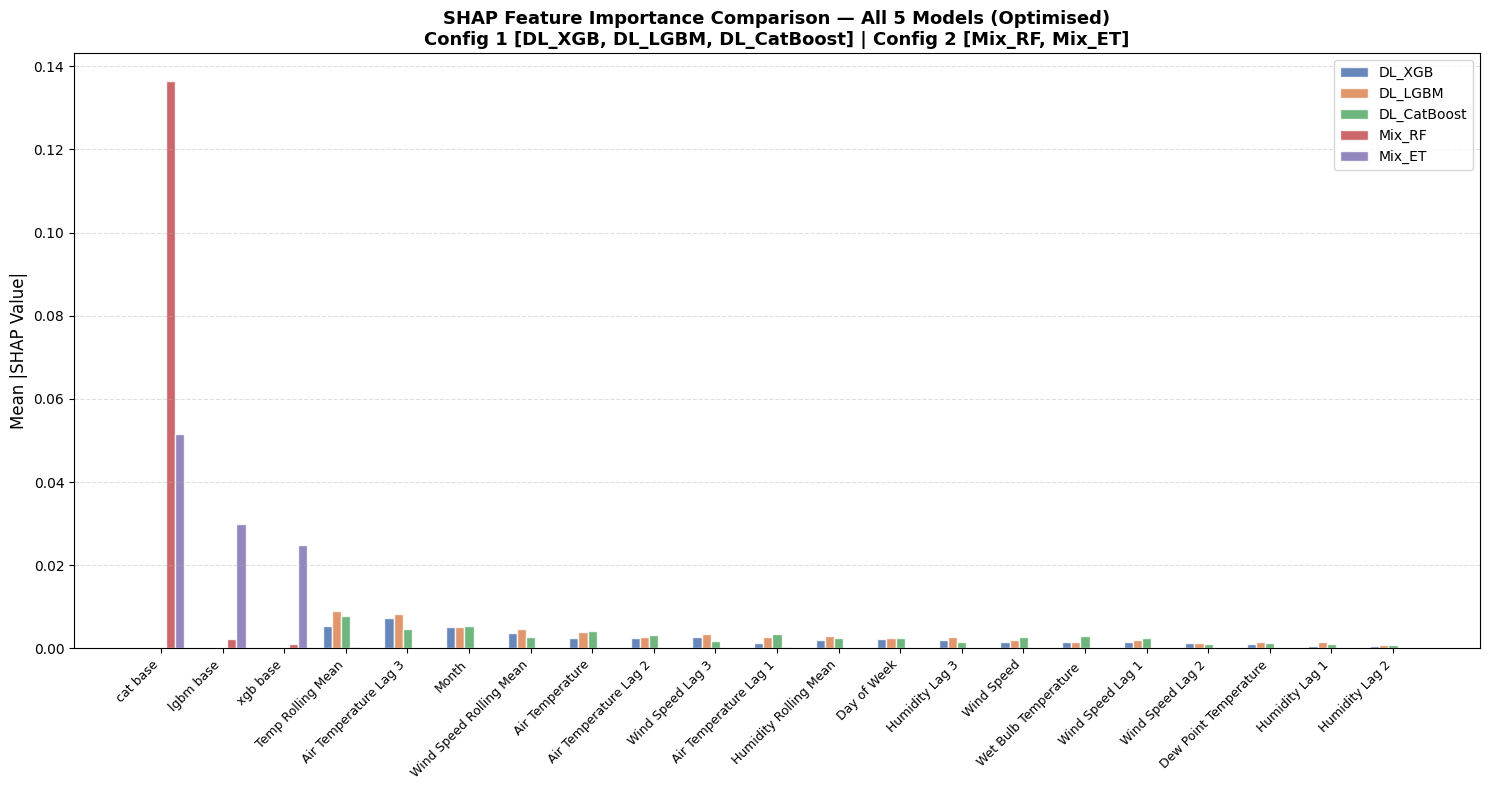

✅ Saved: shap_comparison_all5_bar.png


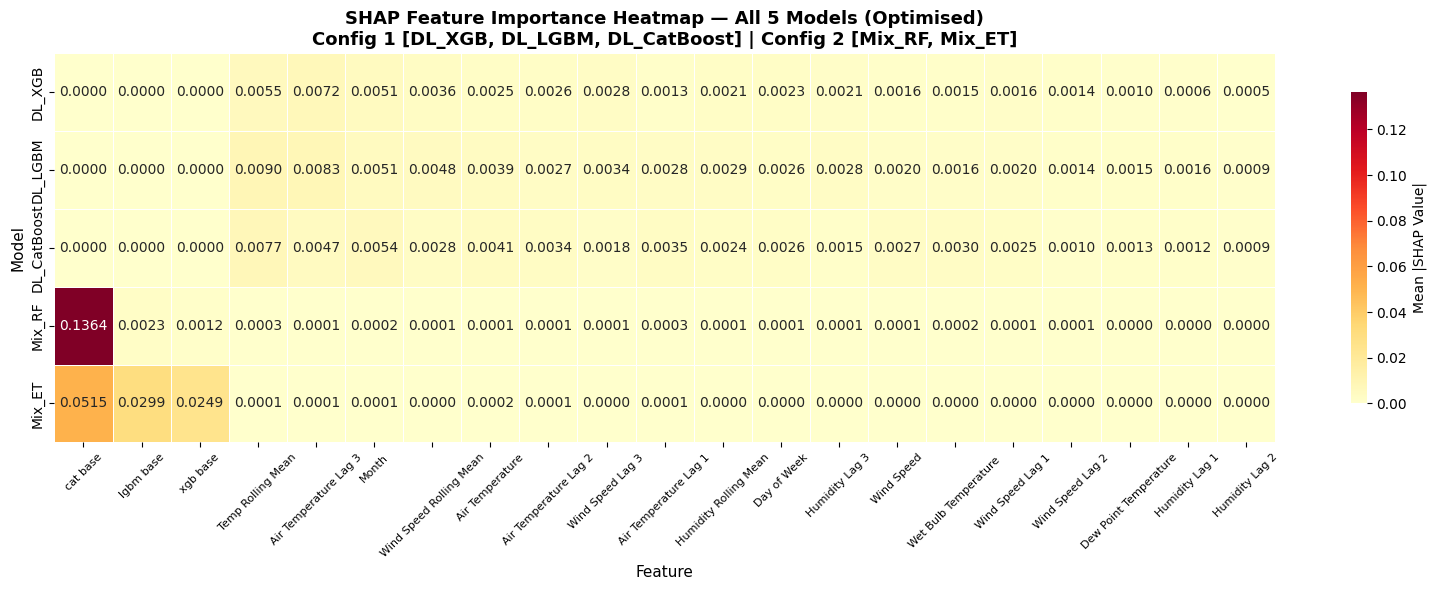

✅ Saved: shap_comparison_all5_heatmap.png

📋 FINAL SHAP RANKING SUMMARY — ALL 5 MODELS

  🔹 DL_XGB — Top 10 Features:
 Rank                 Feature  Mean |SHAP|
    1   Air_Temperature_Lag_3     0.007210
    2       Temp_Rolling_Mean     0.005489
    3                   Month     0.005067
    4 Wind_Speed_Rolling_Mean     0.003621
    5        Wind_Speed_Lag_3     0.002754
    6   Air_Temperature_Lag_2     0.002629
    7         Air_Temperature     0.002472
    8             Day_of_Week     0.002270
    9   Humidity_Rolling_Mean     0.002138
   10          Humidity_Lag_3     0.002051

  🔹 DL_LGBM — Top 10 Features:
 Rank                 Feature  Mean |SHAP|
    1       Temp_Rolling_Mean     0.008951
    2   Air_Temperature_Lag_3     0.008304
    3                   Month     0.005077
    4 Wind_Speed_Rolling_Mean     0.004782
    5         Air_Temperature     0.003852
    6        Wind_Speed_Lag_3     0.003395
    7   Humidity_Rolling_Mean     0.002923
    8   Air_Temperature_Lag_1    

In [15]:
# =========================================
# 🔧 BLOCK 7: SHAP ANALYSIS
# Optimised versions only
# Config 1: DL_XGB, DL_LGBM, DL_CatBoost
#   Input: raw features + bilstm + bigru + tcn predictions
# Config 2: Mix_RF, Mix_ET
#   Input: raw features + bilstm + bigru + tcn + xgb_base + lgbm_base + cat_base
# Plots: Bar Summary + Heatmap — all 5 separately + combined
# NOTE: bilstm, bigru, tcn excluded from SHAP plots (raw features only)
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional, Input
from scikeras.wrappers import KerasRegressor
from tcn import TCN

print("✅ Libraries loaded")

# =========================================
# 📂 LOAD DATA
# =========================================
df = pd.read_csv("reduced_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")
target = "Solar_Radiation_(All_Sky)"
leakage_cols = [
    "Solar_Radiation_(Clear_Sky)",
    "Solar_Radiation_(All_Sky)_Lag_1",
    "Solar_Radiation_(All_Sky)_Lag_2",
    "Solar_Radiation_(All_Sky)_Lag_3",
    "Fourier_Transform_Solar_Radiation"
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
X = df.drop(columns=[target])
y = df[target]

# Fixed split — same seed as optimised runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_train_seq = np.expand_dims(X_train_s, axis=1)
X_test_seq  = np.expand_dims(X_test_s, axis=1)
INPUT_SHAPE = (X_train_seq.shape[1], X_train_seq.shape[2])

print(f"✅ Data ready: {X.shape}")

# =========================================
# 🧠 REBUILD DL MODELS (Optimised params)
# best_tcn_params and best_tcn_dilations
# must be in memory from Block 6
# =========================================
def build_bilstm():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def build_bigru():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Bidirectional(GRU(64, return_sequences=True)),
        Bidirectional(GRU(32)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def build_tcn_opt():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        TCN(
            nb_filters=best_tcn_params["nb_filters"],
            kernel_size=best_tcn_params["kernel_size"],
            dropout_rate=best_tcn_params["dropout_rate"],
            dilations=best_tcn_dilations,
            return_sequences=False
        ),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

print("\n⏳ Training BiLSTM...")
bilstm = KerasRegressor(model=build_bilstm, epochs=5, batch_size=64, verbose=0)
bilstm.fit(X_train_seq, y_train)

print("⏳ Training BiGRU...")
bigru = KerasRegressor(model=build_bigru, epochs=5, batch_size=64, verbose=0)
bigru.fit(X_train_seq, y_train)

print("⏳ Training TCN (Optimised)...")
tcn = KerasRegressor(
    model=build_tcn_opt,
    epochs=best_tcn_params["epochs"],
    batch_size=best_tcn_params["batch_size"],
    verbose=0
)
tcn.fit(X_train_seq, y_train)

# =========================================
# 🔗 CONFIG 1 FEATURE MATRIX
# raw + bilstm + bigru + tcn
# =========================================
X_train_h = X_train.copy()
X_test_h  = X_test.copy()

X_train_h["bilstm"] = bilstm.predict(X_train_seq)
X_train_h["bigru"]  = bigru.predict(X_train_seq)
X_train_h["tcn"]    = tcn.predict(X_train_seq)

X_test_h["bilstm"]  = bilstm.predict(X_test_seq)
X_test_h["bigru"]   = bigru.predict(X_test_seq)
X_test_h["tcn"]     = tcn.predict(X_test_seq)

print(f"✅ Config 1 feature matrix: {X_train_h.shape}")

# =========================================
# 🔗 CONFIG 2 FEATURE MATRIX
# raw + bilstm + bigru + tcn + xgb_base + lgbm_base + cat_base
# =========================================
print("\n⏳ Training ML base learners for Config 2...")

xgb_base  = XGBRegressor(**{**best_xgb_params,  "n_jobs": -1})
lgbm_base = LGBMRegressor(**{**best_lgbm_params, "verbose": -1})
cat_base  = CatBoostRegressor(**{**best_cat_params, "verbose": 0, "random_state": 42})

xgb_base.fit(X_train, y_train)
lgbm_base.fit(X_train, y_train)
cat_base.fit(X_train, y_train)

X_train_meta = X_train.copy()
X_test_meta  = X_test.copy()

# DL predictions
X_train_meta["bilstm"]    = bilstm.predict(X_train_seq)
X_train_meta["bigru"]     = bigru.predict(X_train_seq)
X_train_meta["tcn"]       = tcn.predict(X_train_seq)

# ML base predictions
X_train_meta["xgb_base"]  = xgb_base.predict(X_train)
X_train_meta["lgbm_base"] = lgbm_base.predict(X_train)
X_train_meta["cat_base"]  = cat_base.predict(X_train)

# Test
X_test_meta["bilstm"]     = bilstm.predict(X_test_seq)
X_test_meta["bigru"]      = bigru.predict(X_test_seq)
X_test_meta["tcn"]        = tcn.predict(X_test_seq)

X_test_meta["xgb_base"]   = xgb_base.predict(X_test)
X_test_meta["lgbm_base"]  = lgbm_base.predict(X_test)
X_test_meta["cat_base"]   = cat_base.predict(X_test)

print(f"✅ Config 2 feature matrix: {X_train_meta.shape}")

# =========================================
# 🚫 COLUMNS TO EXCLUDE FROM SHAP PLOTS
# DL predictions used for training but not shown
# =========================================
DL_COLS = ["bilstm", "bigru", "tcn"]

# =========================================
# 🎨 SHAP PLOT FUNCTIONS
# =========================================
TOP_N  = 15
N_BINS = 10

def plot_shap_bar(shap_values, X_data, model_name, save_prefix, exclude_cols=DL_COLS):
    shap_df  = pd.DataFrame(shap_values.values, columns=X_data.columns)

    # ── Drop DL prediction columns before plotting ──
    drop_present = [c for c in exclude_cols if c in shap_df.columns]
    shap_df = shap_df.drop(columns=drop_present)

    mean_abs = shap_df.abs().mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(11, 8))
    colors = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(mean_abs)))

    bars = ax.barh(
        mean_abs.index[::-1],
        mean_abs.values[::-1],
        color=colors[::-1],
        edgecolor='white', linewidth=0.5
    )
    for bar, val in zip(bars, mean_abs.values[::-1]):
        ax.text(
            bar.get_width() + mean_abs.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va='center', ha='left', fontsize=8
        )

    ax.set_xlabel("Mean |SHAP Value|", fontsize=12)
    ax.set_title(
        f"SHAP Feature Importance — {model_name} (Optimised)\nMean |SHAP| per Feature",
        fontsize=13, fontweight='bold'
    )
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()

    fname = f"{save_prefix}_shap_bar.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Saved: {fname}")
    plt.close()
    return mean_abs


def plot_shap_heatmap(shap_values, X_data, model_name, save_prefix, exclude_cols=DL_COLS):
    shap_df  = pd.DataFrame(shap_values.values, columns=X_data.columns)

    # ── Drop DL prediction columns before plotting ──
    drop_present = [c for c in exclude_cols if c in shap_df.columns]
    shap_df = shap_df.drop(columns=drop_present)

    mean_abs     = shap_df.abs().mean().sort_values(ascending=False)
    top_features = mean_abs.head(TOP_N).index.tolist()
    shap_top     = shap_df[top_features].copy()

    bin_labels = [f"G{i+1}" for i in range(N_BINS)]
    shap_top["bin"] = pd.cut(range(len(shap_top)), bins=N_BINS, labels=bin_labels)
    heatmap_data    = shap_top.groupby("bin")[top_features].mean()
    clean_names     = [f.replace("_", " ") for f in top_features]

    fig, ax = plt.subplots(figsize=(15, 8))
    sns.heatmap(
        heatmap_data.T,
        cmap="RdBu_r", center=0,
        annot=True, fmt=".3f",
        linewidths=0.5, linecolor='white',
        ax=ax,
        cbar_kws={"label": "Mean SHAP Value", "shrink": 0.8},
        yticklabels=clean_names
    )
    ax.set_title(
        f"SHAP Heatmap — {model_name} (Optimised)\n"
        f"Top {TOP_N} Features × {N_BINS} Sample Groups",
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel("Sample Groups", fontsize=11)
    ax.set_ylabel("Feature", fontsize=11)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9)
    plt.tight_layout()

    fname = f"{save_prefix}_shap_heatmap.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Saved: {fname}")
    plt.close()


def run_shap_analysis(model, X_train_data, X_test_data, model_name, save_prefix):
    print(f"\n{'='*55}")
    print(f"🔍 SHAP Analysis: {model_name}")
    print(f"{'='*55}")

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer(X_test_data)
    print(f"  ✅ SHAP values computed: {shap_vals.values.shape}")

    mean_abs = plot_shap_bar(shap_vals, X_test_data, model_name, save_prefix)
    plot_shap_heatmap(shap_vals, X_test_data, model_name, save_prefix)

    # ── Table also excludes DL columns ──
    shap_table = mean_abs.reset_index()
    shap_table.columns = ["Feature", "Mean |SHAP|"]
    shap_table["Rank"] = range(1, len(shap_table)+1)
    print(f"\n  📋 Mean |SHAP| Table — {model_name}:")
    print(shap_table[["Rank","Feature","Mean |SHAP|"]].to_string(index=False))

    fname = f"{save_prefix}_shap_table.csv"
    shap_table.to_csv(fname, index=False)
    print(f"  ✅ Table saved: {fname}")

    return shap_vals, mean_abs

# =========================================
# 📌 CONFIG 1 — DL_XGB
# Input: raw + bilstm + bigru + tcn
# =========================================
print("\n🚀 CONFIG 1: Training DL_XGB (Optimised)...")
dl_xgb = XGBRegressor(**{**best_xgb_params, "n_jobs": -1})
dl_xgb.fit(X_train_h, y_train)
shap_xgb, imp_xgb = run_shap_analysis(
    dl_xgb, X_train_h, X_test_h,
    model_name="DL_XGB", save_prefix="shap_dl_xgb"
)

# =========================================
# 📌 CONFIG 1 — DL_LGBM
# =========================================
print("\n🚀 CONFIG 1: Training DL_LGBM (Optimised)...")
dl_lgbm = LGBMRegressor(**{**best_lgbm_params, "verbose": -1})
dl_lgbm.fit(X_train_h, y_train)
shap_lgbm, imp_lgbm = run_shap_analysis(
    dl_lgbm, X_train_h, X_test_h,
    model_name="DL_LGBM", save_prefix="shap_dl_lgbm"
)

# =========================================
# 📌 CONFIG 1 — DL_CatBoost
# =========================================
print("\n🚀 CONFIG 1: Training DL_CatBoost (Optimised)...")
dl_cat = CatBoostRegressor(**{**best_cat_params, "verbose": 0, "random_state": 42})
dl_cat.fit(X_train_h, y_train)
shap_cat, imp_cat = run_shap_analysis(
    dl_cat, X_train_h, X_test_h,
    model_name="DL_CatBoost", save_prefix="shap_dl_catboost"
)

# =========================================
# 📌 CONFIG 2 — Mix_RF
# Input: raw + bilstm + bigru + tcn + xgb_base + lgbm_base + cat_base
# =========================================
print("\n🚀 CONFIG 2: Training Mix_RF (Optimised)...")
mix_rf = RandomForestRegressor(**{**best_rf_params, "random_state": 42, "n_jobs": -1})
mix_rf.fit(X_train_meta, y_train)
shap_rf, imp_rf = run_shap_analysis(
    mix_rf, X_train_meta, X_test_meta,
    model_name="Mix_RF", save_prefix="shap_mix_rf"
)

# =========================================
# 📌 CONFIG 2 — Mix_ET
# =========================================
print("\n🚀 CONFIG 2: Training Mix_ET (Optimised)...")
mix_et = ExtraTreesRegressor(**{**best_et_params, "random_state": 42, "n_jobs": -1})
mix_et.fit(X_train_meta, y_train)
shap_et, imp_et = run_shap_analysis(
    mix_et, X_train_meta, X_test_meta,
    model_name="Mix_ET", save_prefix="shap_mix_et"
)

# =========================================
# 📊 COMBINED COMPARISON — ALL 5 MODELS
# Note: Config 1 and Config 2 have different
# feature spaces so we align on common features.
# bilstm / bigru / tcn excluded from comparison too.
# =========================================
print("\n" + "="*60)
print("📊 COMBINED SHAP COMPARISON — ALL 5 MODELS")
print("="*60)

all_imps = {
    "DL_XGB":      imp_xgb,
    "DL_LGBM":     imp_lgbm,
    "DL_CatBoost": imp_cat,
    "Mix_RF":      imp_rf,
    "Mix_ET":      imp_et,
}

# Union of top 15 features from each model
# imp_* already have DL columns stripped, so no extra filtering needed
top_union = set()
for imp in all_imps.values():
    top_union.update(imp.head(TOP_N).index.tolist())
top_union = list(top_union)

# Build comparison dataframe
comp_df = pd.DataFrame(index=top_union)
for name, imp in all_imps.items():
    comp_df[name] = imp.reindex(top_union).fillna(0)

comp_df["Mean"] = comp_df.mean(axis=1)
comp_df = comp_df.sort_values("Mean", ascending=False).drop(columns="Mean")

print("\n📋 Mean |SHAP| Comparison Table (Top Features, all 5 models):")
print(comp_df.round(5).to_string())
comp_df.to_csv("shap_comparison_all_models.csv")
print("✅ Saved: shap_comparison_all_models.csv")

# ---- Combined Bar Chart ----
fig, ax = plt.subplots(figsize=(15, 8))

x      = np.arange(len(comp_df))
n      = len(all_imps)
width  = 0.15
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for i, (name, color) in enumerate(zip(all_imps.keys(), colors)):
    ax.bar(
        x + i * width,
        comp_df[name].values,
        width,
        label=name,
        color=color,
        alpha=0.85,
        edgecolor='white'
    )

ax.set_xticks(x + width * (n-1) / 2)
ax.set_xticklabels(
    [f.replace("_", " ") for f in comp_df.index],
    rotation=45, ha='right', fontsize=9
)
ax.set_ylabel("Mean |SHAP Value|", fontsize=12)
ax.set_title(
    "SHAP Feature Importance Comparison — All 5 Models (Optimised)\n"
    "Config 1 [DL_XGB, DL_LGBM, DL_CatBoost] | Config 2 [Mix_RF, Mix_ET]",
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("shap_comparison_all5_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_comparison_all5_bar.png")
plt.close()

# ---- Combined Heatmap ----
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    comp_df.T,
    cmap="YlOrRd",
    annot=True, fmt=".4f",
    linewidths=0.5, linecolor='white',
    ax=ax,
    cbar_kws={"label": "Mean |SHAP Value|", "shrink": 0.8},
    xticklabels=[f.replace("_", " ") for f in comp_df.index]
)
ax.set_title(
    "SHAP Feature Importance Heatmap — All 5 Models (Optimised)\n"
    "Config 1 [DL_XGB, DL_LGBM, DL_CatBoost] | Config 2 [Mix_RF, Mix_ET]",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel("Feature", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig("shap_comparison_all5_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_comparison_all5_heatmap.png")
plt.close()

# =========================================
# 📋 FINAL SHAP SUMMARY TABLE
# =========================================
print("\n📋 FINAL SHAP RANKING SUMMARY — ALL 5 MODELS")
print("="*70)
for name, imp in all_imps.items():
    print(f"\n  🔹 {name} — Top 10 Features:")
    top10 = imp.head(10).reset_index()
    top10.columns = ["Feature", "Mean |SHAP|"]
    top10["Rank"] = range(1, 11)
    print(top10[["Rank","Feature","Mean |SHAP|"]].to_string(index=False))

print("\n✅ BLOCK 7 COMPLETE")
print("\n📁 Files saved:")
print("  Per-model (Config 1): shap_dl_xgb_*, shap_dl_lgbm_*, shap_dl_catboost_*")
print("  Per-model (Config 2): shap_mix_rf_*, shap_mix_et_*")
print("  Combined:  shap_comparison_all5_bar.png")
print("             shap_comparison_all5_heatmap.png")
print("             shap_comparison_all_models.csv")


🚀 CONFIG 2: Training Mix_RF (Optimised)...
  ✅ Mix_RF trained

🔍 SHAP Analysis: Mix_RF
  ✅ SHAP values computed: (4983, 25)


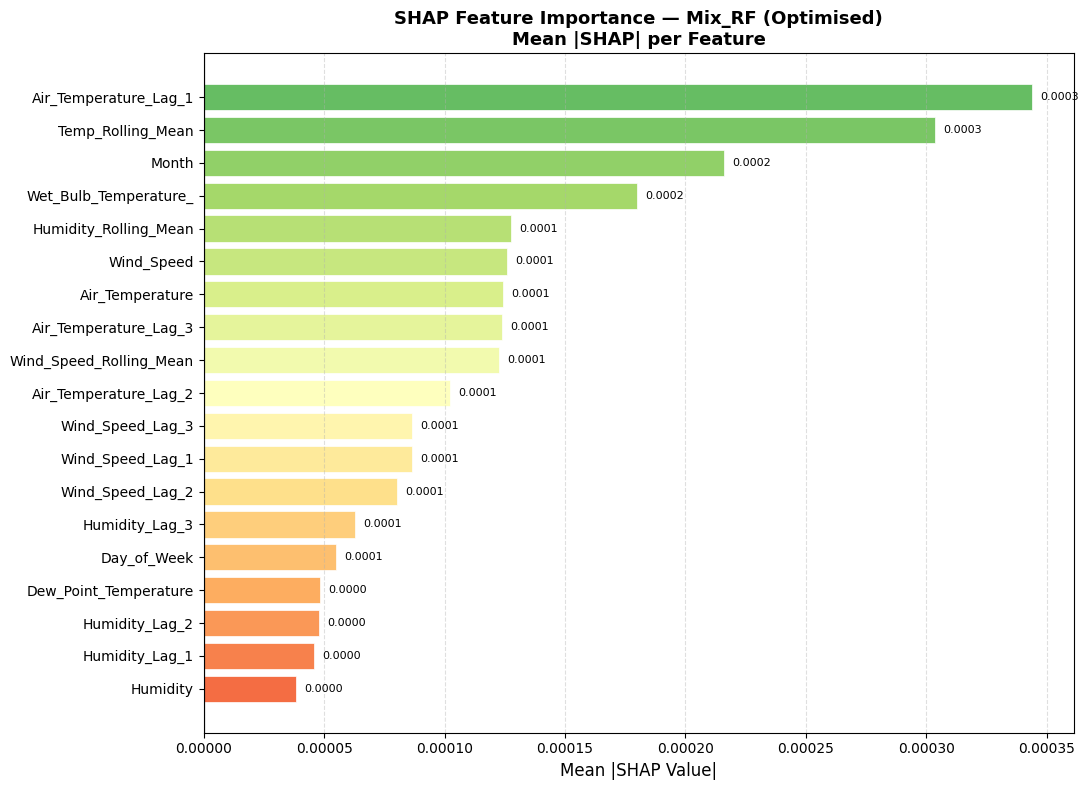

  ✅ Saved: shap_mix_rf_shap_bar.png


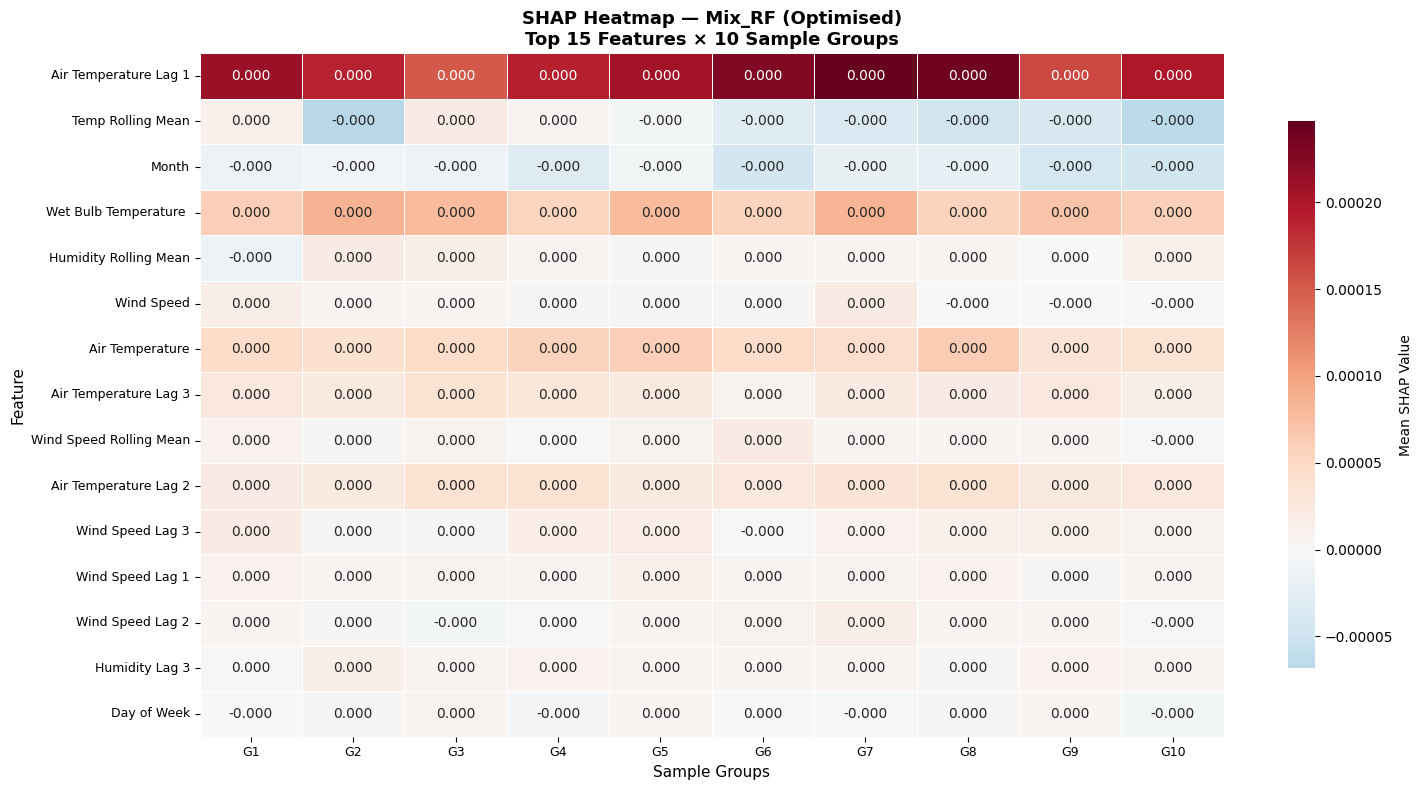

  ✅ Saved: shap_mix_rf_shap_heatmap.png

  📋 Mean |SHAP| Table — Mix_RF:
 Rank                 Feature  Mean |SHAP|
    1   Air_Temperature_Lag_1     0.000344
    2       Temp_Rolling_Mean     0.000304
    3                   Month     0.000216
    4   Wet_Bulb_Temperature_     0.000180
    5   Humidity_Rolling_Mean     0.000128
    6              Wind_Speed     0.000126
    7         Air_Temperature     0.000124
    8   Air_Temperature_Lag_3     0.000124
    9 Wind_Speed_Rolling_Mean     0.000123
   10   Air_Temperature_Lag_2     0.000102
   11        Wind_Speed_Lag_3     0.000087
   12        Wind_Speed_Lag_1     0.000086
   13        Wind_Speed_Lag_2     0.000080
   14          Humidity_Lag_3     0.000063
   15             Day_of_Week     0.000055
   16   Dew_Point_Temperature     0.000048
   17          Humidity_Lag_2     0.000048
   18          Humidity_Lag_1     0.000046
   19                Humidity     0.000038
  ✅ Saved: shap_mix_rf_shap_table.csv

🚀 CONFIG 2: Training Mix_ET 

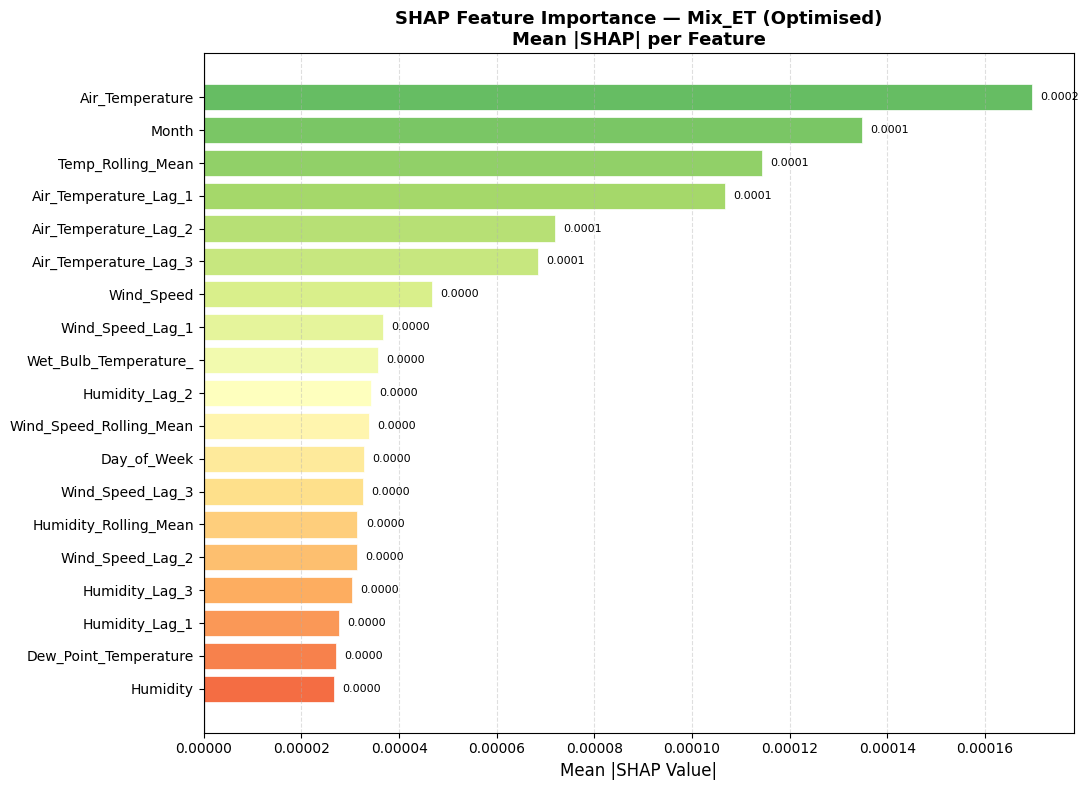

  ✅ Saved: shap_mix_et_shap_bar.png


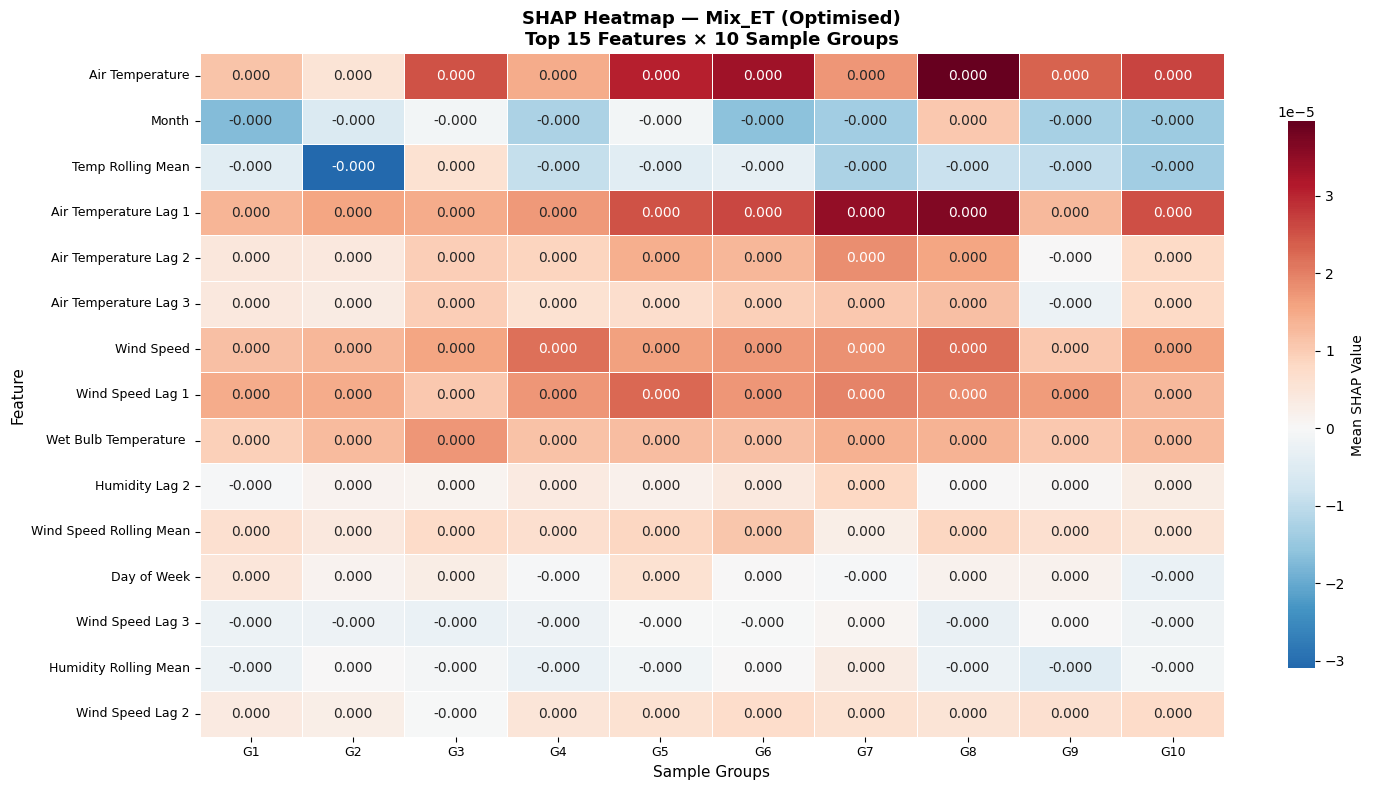

  ✅ Saved: shap_mix_et_shap_heatmap.png

  📋 Mean |SHAP| Table — Mix_ET:
 Rank                 Feature  Mean |SHAP|
    1         Air_Temperature     0.000170
    2                   Month     0.000135
    3       Temp_Rolling_Mean     0.000114
    4   Air_Temperature_Lag_1     0.000107
    5   Air_Temperature_Lag_2     0.000072
    6   Air_Temperature_Lag_3     0.000069
    7              Wind_Speed     0.000047
    8        Wind_Speed_Lag_1     0.000037
    9   Wet_Bulb_Temperature_     0.000036
   10          Humidity_Lag_2     0.000034
   11 Wind_Speed_Rolling_Mean     0.000034
   12             Day_of_Week     0.000033
   13        Wind_Speed_Lag_3     0.000033
   14   Humidity_Rolling_Mean     0.000031
   15        Wind_Speed_Lag_2     0.000031
   16          Humidity_Lag_3     0.000030
   17          Humidity_Lag_1     0.000028
   18   Dew_Point_Temperature     0.000027
   19                Humidity     0.000027
  ✅ Saved: shap_mix_et_shap_table.csv

✅ CONFIG 2 SHAP COMPLETE

📁 

In [16]:
# =========================================
# 🔧 BLOCK 7 — CONFIG 2: Mix_RF & Mix_ET
# Optimised versions only
# Input: raw + bilstm + bigru + tcn + xgb_base + lgbm_base + cat_base
# SHAP Plots: Bar + Heatmap (raw features only in plots)
# NOTE: bilstm, bigru, tcn, xgb_base, lgbm_base, cat_base
#       used for training but excluded from SHAP visualisation
# =========================================

# Columns to hide from all SHAP plots/tables
EXCLUDE_COLS = ["bilstm", "bigru", "tcn", "xgb_base", "lgbm_base", "cat_base"]

TOP_N  = 15
N_BINS = 10

# =========================================
# 📌 CONFIG 2 — Mix_RF (Optimised)
# =========================================
print("\n🚀 CONFIG 2: Training Mix_RF (Optimised)...")
mix_rf = RandomForestRegressor(**{**best_rf_params, "random_state": 42, "n_jobs": -1})
mix_rf.fit(X_train_meta, y_train)
print("  ✅ Mix_RF trained")

# ---- SHAP ----
print("\n" + "="*55)
print("🔍 SHAP Analysis: Mix_RF")
print("="*55)

explainer_rf = shap.TreeExplainer(mix_rf)
shap_rf      = explainer_rf(X_test_meta)
print(f"  ✅ SHAP values computed: {shap_rf.values.shape}")

# --- Bar ---
shap_df_rf   = pd.DataFrame(shap_rf.values, columns=X_test_meta.columns)
shap_df_rf   = shap_df_rf.drop(columns=[c for c in EXCLUDE_COLS if c in shap_df_rf.columns])
imp_rf       = shap_df_rf.abs().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
colors  = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(imp_rf)))
bars    = ax.barh(imp_rf.index[::-1], imp_rf.values[::-1],
                  color=colors[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, imp_rf.values[::-1]):
    ax.text(bar.get_width() + imp_rf.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va='center', ha='left', fontsize=8)
ax.set_xlabel("Mean |SHAP Value|", fontsize=12)
ax.set_title("SHAP Feature Importance — Mix_RF (Optimised)\nMean |SHAP| per Feature",
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("shap_mix_rf_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: shap_mix_rf_shap_bar.png")
plt.close()

# --- Heatmap ---
top_features_rf  = imp_rf.head(TOP_N).index.tolist()
shap_top_rf      = shap_df_rf[top_features_rf].copy()
bin_labels       = [f"G{i+1}" for i in range(N_BINS)]
shap_top_rf["bin"] = pd.cut(range(len(shap_top_rf)), bins=N_BINS, labels=bin_labels)
heatmap_rf       = shap_top_rf.groupby("bin")[top_features_rf].mean()

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(heatmap_rf.T, cmap="RdBu_r", center=0,
            annot=True, fmt=".3f", linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={"label": "Mean SHAP Value", "shrink": 0.8},
            yticklabels=[f.replace("_", " ") for f in top_features_rf])
ax.set_title(f"SHAP Heatmap — Mix_RF (Optimised)\nTop {TOP_N} Features × {N_BINS} Sample Groups",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Sample Groups", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig("shap_mix_rf_shap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: shap_mix_rf_shap_heatmap.png")
plt.close()

# --- Table ---
rf_table = imp_rf.reset_index()
rf_table.columns = ["Feature", "Mean |SHAP|"]
rf_table["Rank"] = range(1, len(rf_table) + 1)
print("\n  📋 Mean |SHAP| Table — Mix_RF:")
print(rf_table[["Rank", "Feature", "Mean |SHAP|"]].to_string(index=False))
rf_table.to_csv("shap_mix_rf_shap_table.csv", index=False)
print("  ✅ Saved: shap_mix_rf_shap_table.csv")

# =========================================
# 📌 CONFIG 2 — Mix_ET (Optimised)
# =========================================
print("\n🚀 CONFIG 2: Training Mix_ET (Optimised)...")
mix_et = ExtraTreesRegressor(**{**best_et_params, "random_state": 42, "n_jobs": -1})
mix_et.fit(X_train_meta, y_train)
print("  ✅ Mix_ET trained")

# ---- SHAP ----
print("\n" + "="*55)
print("🔍 SHAP Analysis: Mix_ET")
print("="*55)

explainer_et = shap.TreeExplainer(mix_et)
shap_et      = explainer_et(X_test_meta)
print(f"  ✅ SHAP values computed: {shap_et.values.shape}")

# --- Bar ---
shap_df_et   = pd.DataFrame(shap_et.values, columns=X_test_meta.columns)
shap_df_et   = shap_df_et.drop(columns=[c for c in EXCLUDE_COLS if c in shap_df_et.columns])
imp_et       = shap_df_et.abs().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
colors  = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(imp_et)))
bars    = ax.barh(imp_et.index[::-1], imp_et.values[::-1],
                  color=colors[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, imp_et.values[::-1]):
    ax.text(bar.get_width() + imp_et.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va='center', ha='left', fontsize=8)
ax.set_xlabel("Mean |SHAP Value|", fontsize=12)
ax.set_title("SHAP Feature Importance — Mix_ET (Optimised)\nMean |SHAP| per Feature",
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("shap_mix_et_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: shap_mix_et_shap_bar.png")
plt.close()

# --- Heatmap ---
top_features_et  = imp_et.head(TOP_N).index.tolist()
shap_top_et      = shap_df_et[top_features_et].copy()
shap_top_et["bin"] = pd.cut(range(len(shap_top_et)), bins=N_BINS, labels=bin_labels)
heatmap_et       = shap_top_et.groupby("bin")[top_features_et].mean()

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(heatmap_et.T, cmap="RdBu_r", center=0,
            annot=True, fmt=".3f", linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={"label": "Mean SHAP Value", "shrink": 0.8},
            yticklabels=[f.replace("_", " ") for f in top_features_et])
ax.set_title(f"SHAP Heatmap — Mix_ET (Optimised)\nTop {TOP_N} Features × {N_BINS} Sample Groups",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Sample Groups", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig("shap_mix_et_shap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: shap_mix_et_shap_heatmap.png")
plt.close()

# --- Table ---
et_table = imp_et.reset_index()
et_table.columns = ["Feature", "Mean |SHAP|"]
et_table["Rank"] = range(1, len(et_table) + 1)
print("\n  📋 Mean |SHAP| Table — Mix_ET:")
print(et_table[["Rank", "Feature", "Mean |SHAP|"]].to_string(index=False))
et_table.to_csv("shap_mix_et_shap_table.csv", index=False)
print("  ✅ Saved: shap_mix_et_shap_table.csv")

print("\n✅ CONFIG 2 SHAP COMPLETE")
print("\n📁 Files saved:")
print("  shap_mix_rf_shap_bar.png")
print("  shap_mix_rf_shap_heatmap.png")
print("  shap_mix_rf_shap_table.csv")
print("  shap_mix_et_shap_bar.png")
print("  shap_mix_et_shap_heatmap.png")
print("  shap_mix_et_shap_table.csv")

✅ Libraries loaded
✅ Results loaded: (108, 9)
   Models   : <StringArray>
[     'BiLSTM',       'BiGRU',     'XGBoost',        'LGBM',    'CatBoost',
          'RF',          'ET',      'DL_XGB',     'DL_LGBM', 'DL_CatBoost',
      'Mix_RF',      'Mix_ET',         'TCN']
Length: 13, dtype: str
   Versions : <StringArray>
['Unoptimised', 'Optimised']
Length: 2, dtype: str
   Configs  : <StringArray>
[                   'Both',     'Config1_DL_Boosting',
     'Config2_ML_Stacking', 'Config1_DL_Boosting_TCN',
 'Config2_ML_Stacking_TCN']
Length: 5, dtype: str

🔬 PAIRED T-TEST: OPTIMISED vs UNOPTIMISED
Significance: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant


──────────────────────────────────────────────────────────────────────
  📐 R2 — Paired t-test Results
──────────────────────────────────────────────────────────────────────
      Model  Unopt Mean  Opt Mean  t-stat  p-value Sig Improved
     DL_XGB      0.8989    0.9332 11.8563  0.00704  **        ✅
    DL_LGBM      0.9

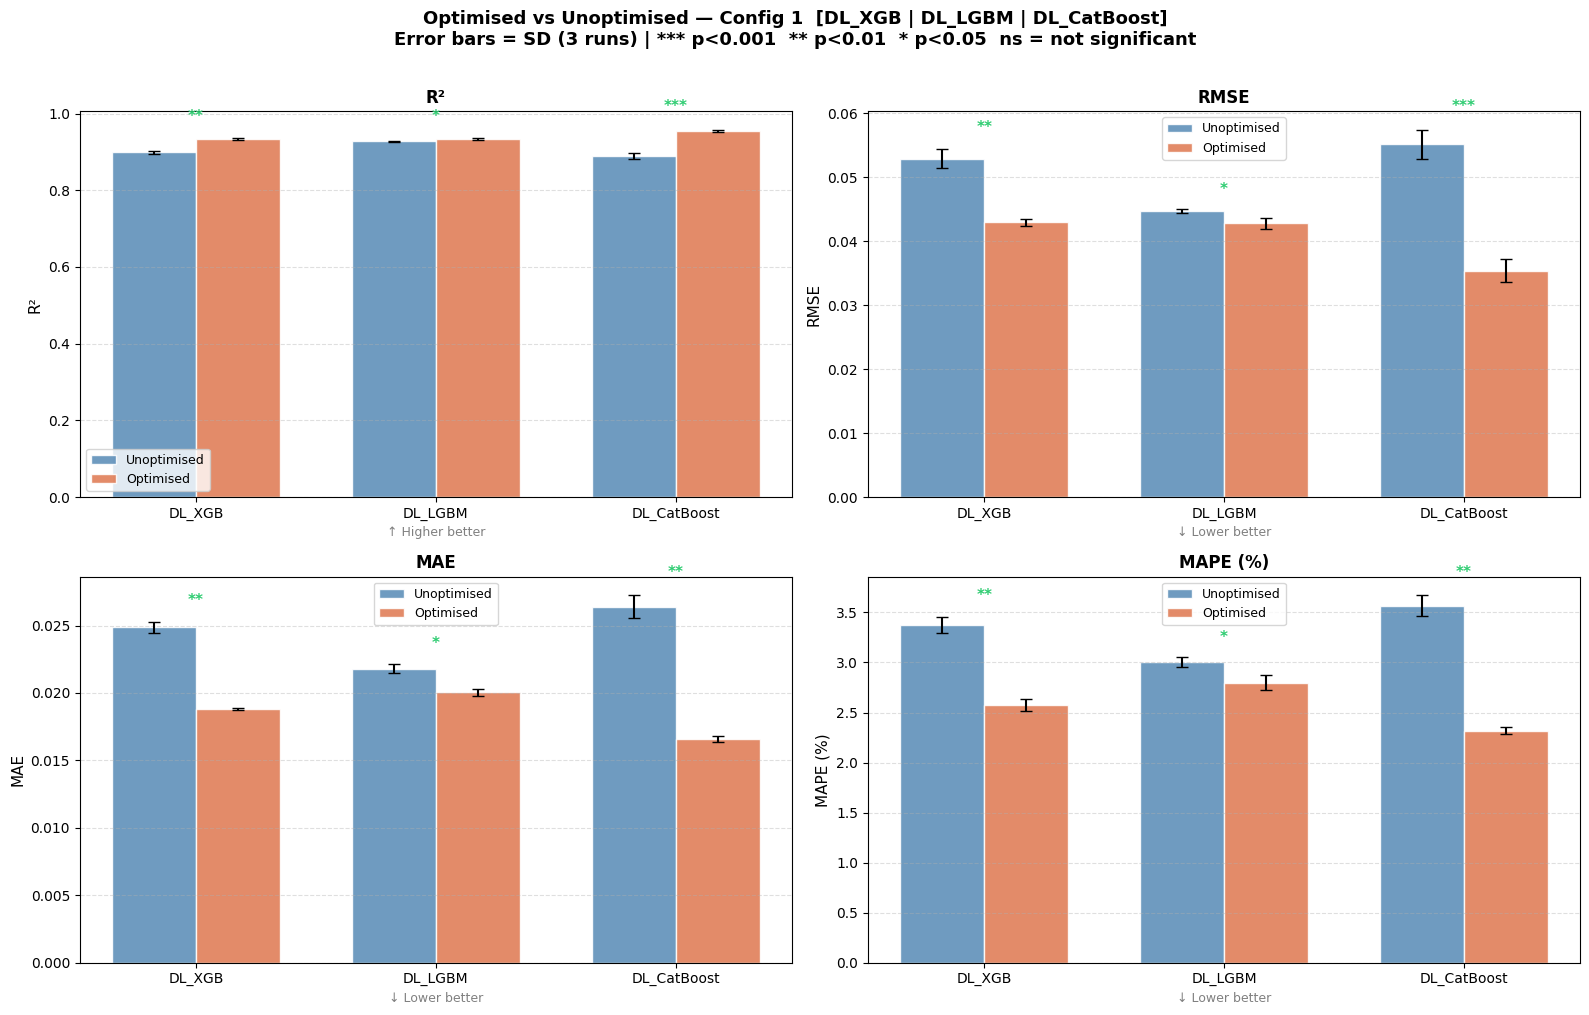

✅ Saved: graph_config1_comparison.png

📊 Generating Graph 2: Config 2 Models...


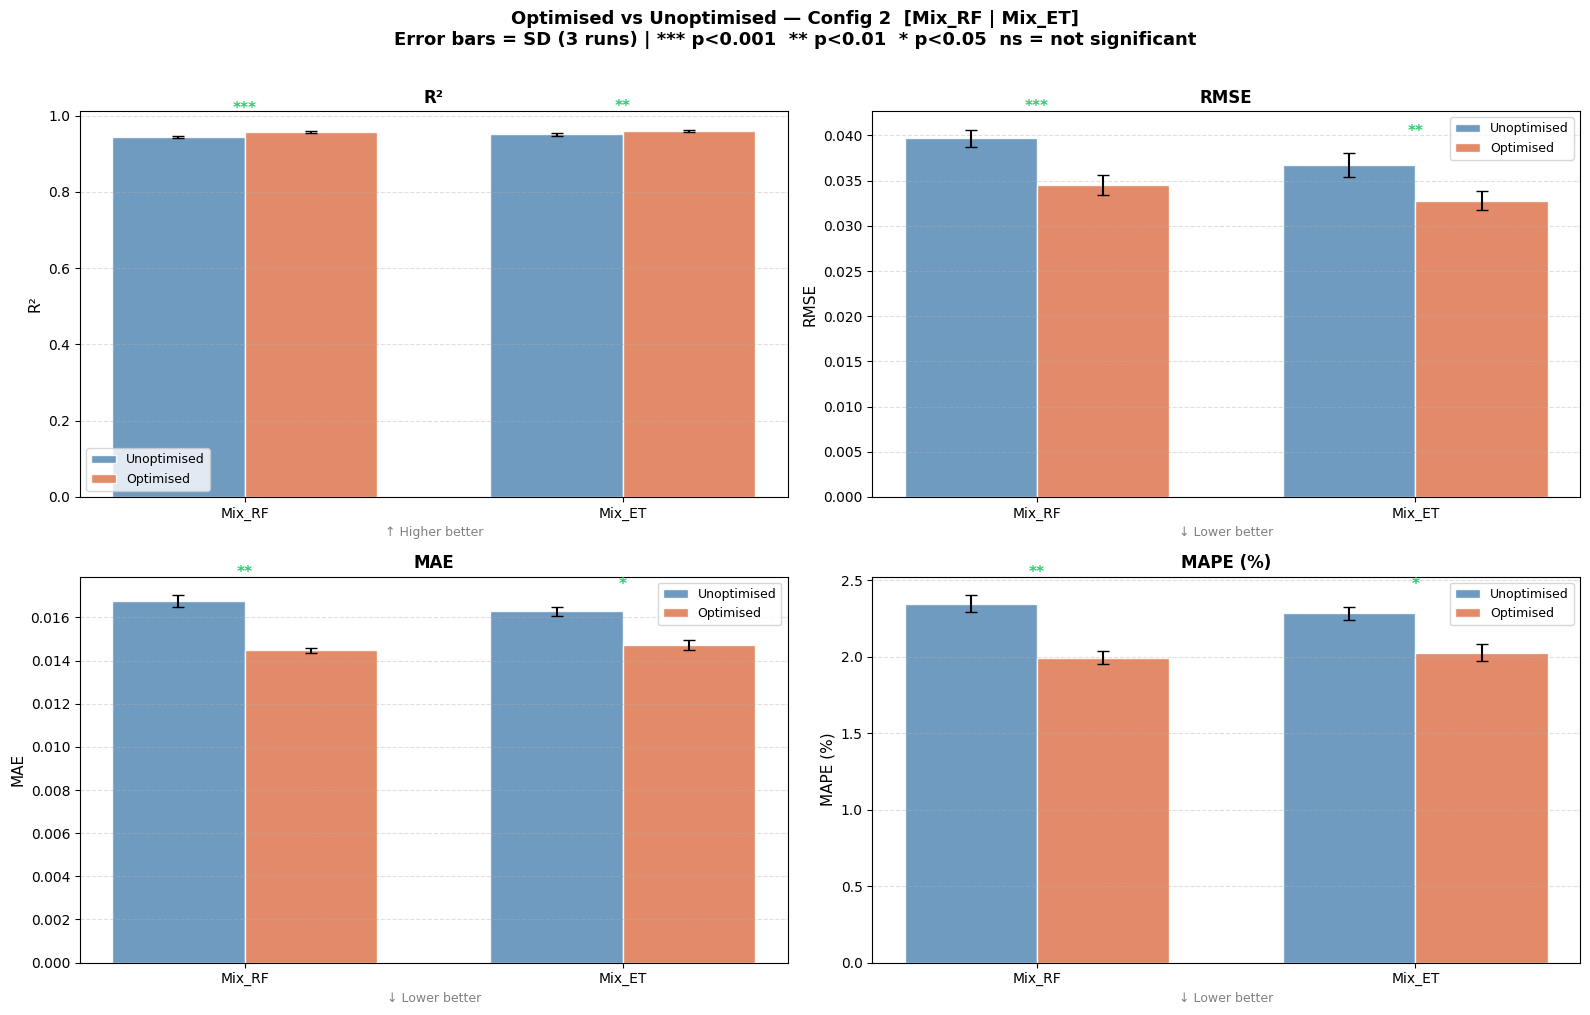

✅ Saved: graph_config2_comparison.png

📋 FULL SIGNIFICANCE TABLE — ALL 5 MODELS × ALL 4 METRICS
Model               R² Unopt      R² Opt   t-stat   p-val  Sig    RMSE Unopt    RMSE Opt   t-stat   p-val  Sig     MAE Unopt     MAE Opt   t-stat   p-val  Sig  MAPE (%) Unopt  MAPE (%) Opt   t-stat   p-val  Sig
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
DL_XGB              0.8989    0.9332   11.856  0.00704   **      0.0528    0.0429  -11.459  0.00753   **      0.0249    0.0188  -24.159  0.00171   **      3.3732    2.5741  -23.403  0.00182   **
DL_LGBM             0.9274    0.9336    5.849  0.02801    *      0.0448    0.0428   -6.001  0.02666    *      0.0218    0.0200   -8.230  0.01444    *      3.0062    2.7985   -4.762  0.04138    *
DL_CatBoost         0.8897    0.9546   32.890  0.00092  ***      0.0552    0.0354  -58.414  0.00029  ***      0.0264    0.0166  -26.961  0.00137   **      3.5664    2.3197 

In [17]:
# =========================================
# 🔧 BLOCK 8: STATISTICAL SIGNIFICANCE TESTS
# Paired t-test: Optimised vs Unoptimised
# For all 5 meta-learners + TCN base
# Graphs: Config1 (DL_XGB, DL_LGBM, DL_CatBoost)
#         Config2 (Mix_RF, Mix_ET)
# Metrics: R², RMSE, MAE, MAPE
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

print("✅ Libraries loaded")

# =========================================
# 📂 LOAD RESULTS
# =========================================
df = pd.read_csv("full_results_all_runs_v2.csv")
print(f"✅ Results loaded: {df.shape}")
print(f"   Models   : {df['Model'].unique()}")
print(f"   Versions : {df['Version'].unique()}")
print(f"   Configs  : {df['Config'].unique()}")

METRICS = ["R2", "RMSE", "MAE", "MAPE"]

# =========================================
# 📌 TARGET MODELS & THEIR CONFIGS
# Use TCN configs (latest rerun)
# =========================================
MODEL_CONFIG = {
    "DL_XGB":      "Config1_DL_Boosting_TCN",
    "DL_LGBM":     "Config1_DL_Boosting_TCN",
    "DL_CatBoost": "Config1_DL_Boosting_TCN",
    "Mix_RF":      "Config2_ML_Stacking_TCN",
    "Mix_ET":      "Config2_ML_Stacking_TCN",
}

# =========================================
# 🔬 PAIRED T-TEST FUNCTION
# =========================================
def paired_ttest(model, config):
    unopt = df[
        (df["Model"] == model) &
        (df["Config"] == config) &
        (df["Version"] == "Unoptimised")
    ].sort_values("Run")

    opt = df[
        (df["Model"] == model) &
        (df["Config"] == config) &
        (df["Version"] == "Optimised")
    ].sort_values("Run")

    if len(unopt) < 3 or len(opt) < 3:
        return None

    results = {"Model": model}
    for metric in METRICS:
        u_vals = unopt[metric].values
        o_vals = opt[metric].values
        t_stat, p_val = stats.ttest_rel(o_vals, u_vals)  # opt vs unopt

        # Direction: for R2 higher opt is better; for RMSE/MAE/MAPE lower is better
        if metric == "R2":
            improved = o_vals.mean() > u_vals.mean()
        else:
            improved = o_vals.mean() < u_vals.mean()

        sig = ""
        if p_val < 0.001:   sig = "***"
        elif p_val < 0.01:  sig = "**"
        elif p_val < 0.05:  sig = "*"
        else:               sig = "ns"

        results[f"{metric}_Unopt_Mean"] = round(u_vals.mean(), 4)
        results[f"{metric}_Opt_Mean"]   = round(o_vals.mean(), 4)
        results[f"{metric}_t_stat"]     = round(t_stat, 4)
        results[f"{metric}_p_value"]    = round(p_val, 5)
        results[f"{metric}_Sig"]        = sig
        results[f"{metric}_Improved"]   = "✅" if improved else "❌"

    return results

# =========================================
# 📊 RUN TESTS FOR ALL 5 MODELS
# =========================================
print("\n" + "="*70)
print("🔬 PAIRED T-TEST: OPTIMISED vs UNOPTIMISED")
print("="*70)
print("Significance: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant\n")

all_results = []
for model, config in MODEL_CONFIG.items():
    r = paired_ttest(model, config)
    if r:
        all_results.append(r)
    else:
        print(f"  ⚠️  Skipped {model} — insufficient runs in data")

ttest_df = pd.DataFrame(all_results)

# =========================================
# 📋 PRINT CLEAN TABLES PER METRIC
# =========================================
for metric in METRICS:
    cols = [
        "Model",
        f"{metric}_Unopt_Mean",
        f"{metric}_Opt_Mean",
        f"{metric}_t_stat",
        f"{metric}_p_value",
        f"{metric}_Sig",
        f"{metric}_Improved"
    ]
    sub = ttest_df[cols].copy()
    sub.columns = [
        "Model",
        "Unopt Mean", "Opt Mean",
        "t-stat", "p-value",
        "Sig", "Improved"
    ]
    print(f"\n{'─'*70}")
    print(f"  📐 {metric} — Paired t-test Results")
    print(f"{'─'*70}")
    print(sub.to_string(index=False))

# =========================================
# 📋 SAVE COMPACT SUMMARY TABLE
# =========================================
# One row per model, columns: Model | metric(unopt) | metric(opt) | t | p | sig
summary_rows = []
for _, row in ttest_df.iterrows():
    entry = {"Model": row["Model"]}
    for metric in METRICS:
        entry[f"{metric} Unopt"] = row[f"{metric}_Unopt_Mean"]
        entry[f"{metric} Opt"]   = row[f"{metric}_Opt_Mean"]
        entry[f"{metric} t"]     = row[f"{metric}_t_stat"]
        entry[f"{metric} p"]     = row[f"{metric}_p_value"]
        entry[f"{metric} Sig"]   = row[f"{metric}_Sig"]
    summary_rows.append(entry)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("ttest_significance_summary.csv", index=False)
print("\n✅ Saved: ttest_significance_summary.csv")

# =========================================
# 🎨 GRAPH HELPERS
# =========================================
UNOPT_COLOR = "#5B8DB8"   # muted blue
OPT_COLOR   = "#E07B54"   # muted orange
SIG_COLOR   = "#2ECC71"   # green asterisk

metric_labels = {"R2": "R²", "RMSE": "RMSE", "MAE": "MAE", "MAPE": "MAPE (%)"}
# For R2: higher is better → improvement arrow up
# For RMSE/MAE/MAPE: lower is better → improvement arrow down
higher_better = {"R2": True, "RMSE": False, "MAE": False, "MAPE": False}


def get_model_runs(model, config, version):
    return df[
        (df["Model"] == model) &
        (df["Config"] == config) &
        (df["Version"] == version)
    ].sort_values("Run")


def annotate_sig(ax, x, y_top, sig, bar_h):
    """Draw significance marker above bar pair."""
    if sig == "ns":
        return
    color = SIG_COLOR
    ax.text(x, y_top + bar_h * 0.05, sig,
            ha='center', va='bottom', fontsize=11,
            color=color, fontweight='bold')


def draw_comparison_chart(models, configs, group_title, save_prefix):
    """
    4-subplot chart (one per metric) with grouped bars
    Unopt (blue) vs Opt (orange) per model.
    Error bars = std across 3 runs.
    """
    n_models = len(models)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax_idx, metric in enumerate(METRICS):
        ax = axes[ax_idx]

        x       = np.arange(n_models)
        width   = 0.35
        unopt_means, unopt_stds = [], []
        opt_means,   opt_stds   = [], []
        sigs = []

        for model, config in zip(models, configs):
            u = get_model_runs(model, config, "Unoptimised")[metric]
            o = get_model_runs(model, config, "Optimised")[metric]
            unopt_means.append(u.mean())
            unopt_stds.append(u.std())
            opt_means.append(o.mean())
            opt_stds.append(o.std())

            # Get sig from ttest_df
            row = ttest_df[ttest_df["Model"] == model]
            sigs.append(row[f"{metric}_Sig"].values[0] if len(row) else "ns")

        b1 = ax.bar(x - width/2, unopt_means, width,
                    yerr=unopt_stds, capsize=4,
                    color=UNOPT_COLOR, alpha=0.88,
                    label="Unoptimised", edgecolor='white')
        b2 = ax.bar(x + width/2, opt_means, width,
                    yerr=opt_stds, capsize=4,
                    color=OPT_COLOR, alpha=0.88,
                    label="Optimised", edgecolor='white')

        # Significance annotations
        for i, sig in enumerate(sigs):
            all_vals = [unopt_means[i] + unopt_stds[i],
                        opt_means[i]   + opt_stds[i]]
            y_top = max(all_vals) * 1.04
            bar_h = max(all_vals) * 0.02
            annotate_sig(ax, x[i], y_top, sig, bar_h)

        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=10)
        ax.set_ylabel(metric_labels[metric], fontsize=11)
        ax.set_title(f"{metric_labels[metric]}", fontsize=12, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.legend(fontsize=9)

        # Shade to indicate direction
        direction = "↑ Higher better" if higher_better[metric] else "↓ Lower better"
        ax.set_xlabel(direction, fontsize=9, color='gray')

    fig.suptitle(
        f"Optimised vs Unoptimised — {group_title}\n"
        "Error bars = SD (3 runs) | *** p<0.001  ** p<0.01  * p<0.05  ns = not significant",
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    fname = f"{save_prefix}_comparison.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {fname}")
    plt.close()


# =========================================
# 📊 GRAPH 1: CONFIG 1 — DL_XGB, DL_LGBM, DL_CatBoost
# =========================================
print("\n📊 Generating Graph 1: Config 1 Models...")
draw_comparison_chart(
    models  = ["DL_XGB", "DL_LGBM", "DL_CatBoost"],
    configs = [
        "Config1_DL_Boosting_TCN",
        "Config1_DL_Boosting_TCN",
        "Config1_DL_Boosting_TCN"
    ],
    group_title  = "Config 1  [DL_XGB | DL_LGBM | DL_CatBoost]",
    save_prefix  = "graph_config1"
)

# =========================================
# 📊 GRAPH 2: CONFIG 2 — Mix_RF, Mix_ET
# =========================================
print("\n📊 Generating Graph 2: Config 2 Models...")
draw_comparison_chart(
    models  = ["Mix_RF", "Mix_ET"],
    configs = [
        "Config2_ML_Stacking_TCN",
        "Config2_ML_Stacking_TCN"
    ],
    group_title  = "Config 2  [Mix_RF | Mix_ET]",
    save_prefix  = "graph_config2"
)

# =========================================
# 📋 PRINT FULL CONSOLIDATED TABLE
# =========================================
print("\n" + "="*90)
print("📋 FULL SIGNIFICANCE TABLE — ALL 5 MODELS × ALL 4 METRICS")
print("="*90)
print(f"{'Model':<14}", end="")
for metric in METRICS:
    print(f"  {metric_labels[metric]:>6} Unopt  {metric_labels[metric]:>6} Opt   t-stat   p-val  Sig", end="")
print()
print("─" * 130)

for _, row in ttest_df.iterrows():
    print(f"{row['Model']:<14}", end="")
    for metric in METRICS:
        print(
            f"  {row[f'{metric}_Unopt_Mean']:>10.4f}"
            f"  {row[f'{metric}_Opt_Mean']:>8.4f}"
            f"  {row[f'{metric}_t_stat']:>7.3f}"
            f"  {row[f'{metric}_p_value']:>7.5f}"
            f"  {row[f'{metric}_Sig']:>3}",
            end=""
        )
    print()

print("\n✅ BLOCK 8 COMPLETE")
print("\n📁 Files saved:")
print("  ttest_significance_summary.csv")
print("  graph_config1_comparison.png")
print("  graph_config2_comparison.png")